In [1]:
import pandas as pd

# Define the path to your CSV file
csv_file_path = '/content/Employee-Attrition - Employee-Attrition.csv'
# Load the dataset
try:
    df = pd.read_csv(csv_file_path)
    print("Dataset loaded successfully.")

    # Display the first few rows of the dataframe
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # Check for missing values
    print("\nMissing values per column:")
    print(df.isnull().sum())

    # Display data types of each column
    print("\nData types of each column:")
    print(df.info())

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully.

First 5 rows of the dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  Relatio

In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# 1. Drop irrelevant columns
# Columns like 'EmployeeCount', 'StandardHours', 'Over18' have only one unique value or are constant.
# 'EmployeeNumber' is a unique identifier and not useful as a feature.
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_cleaned = df.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")

# 2. Convert target variable 'Attrition' to numerical (0 and 1)
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'No': 0, 'Yes': 1})
print("\n'Attrition' column converted to numerical (0 for No, 1 for Yes).")

# 3. Handle other categorical variables using one-hot encoding
# Identify categorical columns (object dtype)
categorical_cols = df_cleaned.select_dtypes(include='object').columns

print(f"\nApplying One-Hot Encoding to categorical columns: {list(categorical_cols)}")

# Apply one-hot encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

print("\nData cleaning complete. Here are the first 5 rows of the cleaned data:")
print(df_cleaned.head())

print("\nAnd the data types after cleaning:")
print(df_cleaned.info())

Dropped columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']

'Attrition' column converted to numerical (0 for No, 1 for Yes).

Applying One-Hot Encoding to categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Data cleaning complete. Here are the first 5 rows of the cleaned data:
   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2     

In [4]:
import os

output_csv_path = '/content/cleaned_employee_attrition.csv'
df_cleaned.to_csv(output_csv_path, index=False)

print(f"Cleaned data saved to {output_csv_path}")

# Provide a link to download the file directly in Colab
from google.colab import files
files.download(output_csv_path)

Cleaned data saved to /content/cleaned_employee_attrition.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exploratory Data Analysis (EDA)

In [5]:
print(f"Shape of df_cleaned before removing duplicates: {df_cleaned.shape}")

# Check for duplicate rows
num_duplicates = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows found: {num_duplicates}")

# Remove duplicate rows
if num_duplicates > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate rows to remove.")

print(f"Shape of df_cleaned after removing duplicates: {df_cleaned.shape}")

Shape of df_cleaned before removing duplicates: (1470, 45)
Number of duplicate rows found: 0
No duplicate rows to remove.
Shape of df_cleaned after removing duplicates: (1470, 45)


In [6]:
print("Descriptive statistics for numerical columns:")
print(df_cleaned.describe())

Descriptive statistics for numerical columns:
               Age    Attrition    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810     0.161224   802.485714          9.192517     2.912925   
std       9.135373     0.367863   403.509100          8.106864     1.024165   
min      18.000000     0.000000   102.000000          1.000000     1.000000   
25%      30.000000     0.000000   465.000000          2.000000     2.000000   
50%      36.000000     0.000000   802.000000          7.000000     3.000000   
75%      43.000000     0.000000  1157.000000         14.000000     4.000000   
max      60.000000     1.000000  1499.000000         29.000000     5.000000   

       EnvironmentSatisfaction   HourlyRate  JobInvolvement     JobLevel  \
count              1470.000000  1470.000000     1470.000000  1470.000000   
mean                  2.721769    65.891156        2.729932     2.063946   
std           

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries seaborn and matplotlib.pyplot imported.")

Libraries seaborn and matplotlib.pyplot imported.


/tmp/ipython-input-3655787943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df_cleaned, ax=axes[0, 0], palette='viridis')
/tmp/ipython-input-3655787943.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender_Male', data=df_cleaned, ax=axes[0, 1], palette='plasma')
/tmp/ipython-input-3655787943.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Department_Sales', data=df_cleaned, ax=axes[1, 0], palette='magma')
/tmp/ipython-input-3655787943.py:23: FutureWarning: 

Passing `palette` without assigning

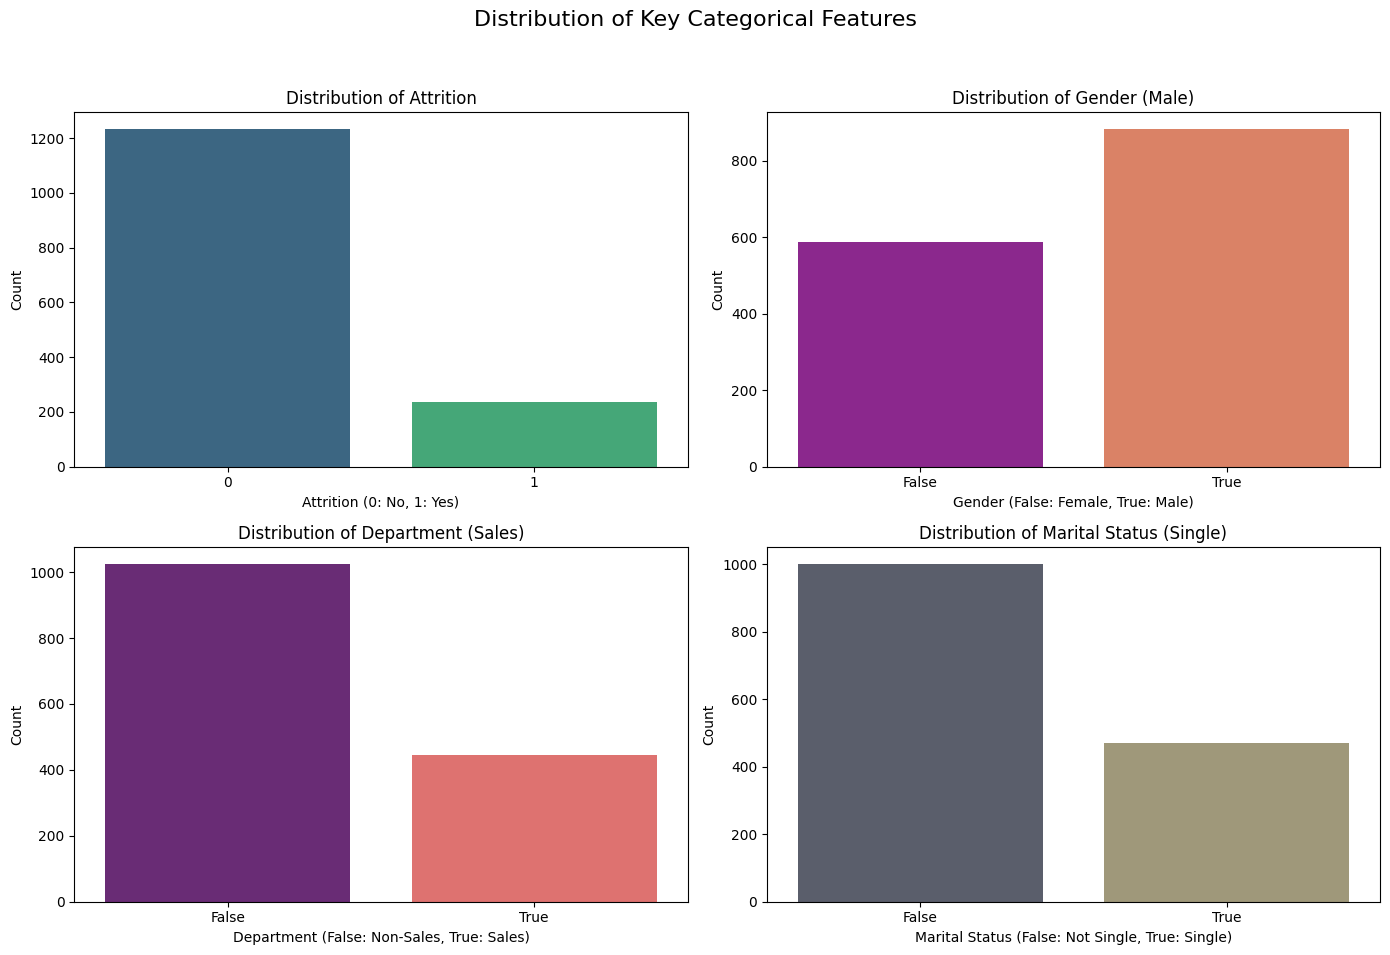

Count plots for 'Attrition', 'Gender_Male', 'Department_Sales', and 'MaritalStatus_Single' displayed.


In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Distribution of Key Categorical Features', fontsize=16)

# Plot for 'Attrition'
sns.countplot(x='Attrition', data=df_cleaned, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution of Attrition')
axes[0, 0].set_xlabel('Attrition (0: No, 1: Yes)')
axes[0, 0].set_ylabel('Count')

# Plot for 'Gender_Male'
sns.countplot(x='Gender_Male', data=df_cleaned, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Distribution of Gender (Male)')
axes[0, 1].set_xlabel('Gender (False: Female, True: Male)')
axes[0, 1].set_ylabel('Count')

# Plot for 'Department_Sales'
sns.countplot(x='Department_Sales', data=df_cleaned, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Distribution of Department (Sales)')
axes[1, 0].set_xlabel('Department (False: Non-Sales, True: Sales)')
axes[1, 0].set_ylabel('Count')

# Plot for 'MaritalStatus_Single'
sns.countplot(x='MaritalStatus_Single', data=df_cleaned, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Distribution of Marital Status (Single)')
axes[1, 1].set_xlabel('Marital Status (False: Not Single, True: Single)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Count plots for 'Attrition', 'Gender_Male', 'Department_Sales', and 'MaritalStatus_Single' displayed.")

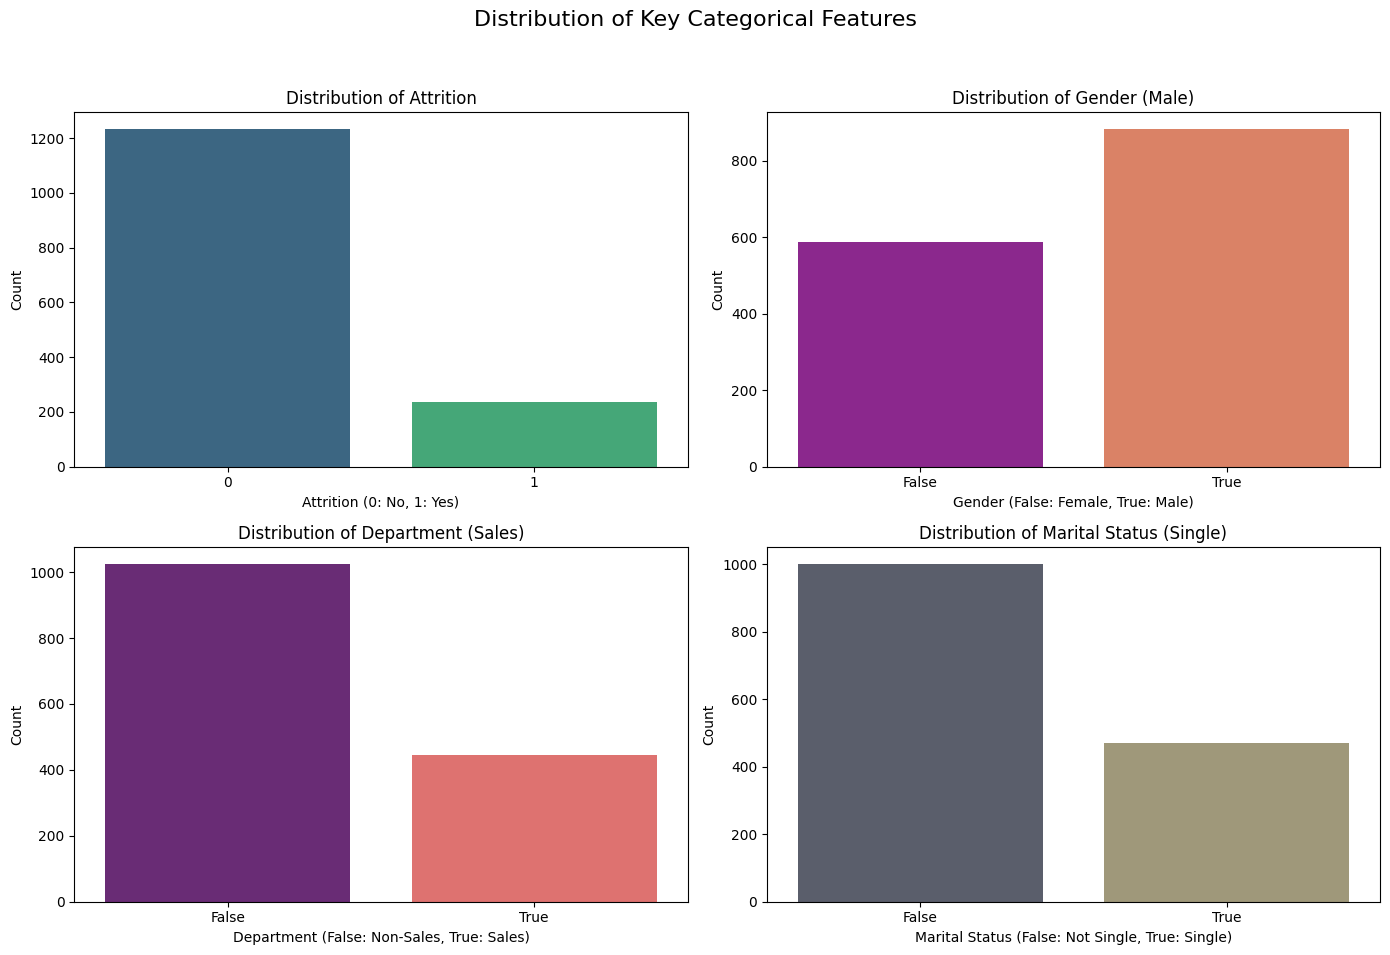

Count plots for 'Attrition', 'Gender_Male', 'Department_Sales', and 'MaritalStatus_Single' displayed.


In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Distribution of Key Categorical Features', fontsize=16)

# Plot for 'Attrition'
sns.countplot(x='Attrition', data=df_cleaned, ax=axes[0, 0], palette='viridis', hue='Attrition', legend=False)
axes[0, 0].set_title('Distribution of Attrition')
axes[0, 0].set_xlabel('Attrition (0: No, 1: Yes)')
axes[0, 0].set_ylabel('Count')

# Plot for 'Gender_Male'
sns.countplot(x='Gender_Male', data=df_cleaned, ax=axes[0, 1], palette='plasma', hue='Gender_Male', legend=False)
axes[0, 1].set_title('Distribution of Gender (Male)')
axes[0, 1].set_xlabel('Gender (False: Female, True: Male)')
axes[0, 1].set_ylabel('Count')

# Plot for 'Department_Sales'
sns.countplot(x='Department_Sales', data=df_cleaned, ax=axes[1, 0], palette='magma', hue='Department_Sales', legend=False)
axes[1, 0].set_title('Distribution of Department (Sales)')
axes[1, 0].set_xlabel('Department (False: Non-Sales, True: Sales)')
axes[1, 0].set_ylabel('Count')

# Plot for 'MaritalStatus_Single'
sns.countplot(x='MaritalStatus_Single', data=df_cleaned, ax=axes[1, 1], palette='cividis', hue='MaritalStatus_Single', legend=False)
axes[1, 1].set_title('Distribution of Marital Status (Single)')
axes[1, 1].set_xlabel('Marital Status (False: Not Single, True: Single)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
print("Count plots for 'Attrition', 'Gender_Male', 'Department_Sales', and 'MaritalStatus_Single' displayed.")

Identified 24 numerical columns for plotting:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


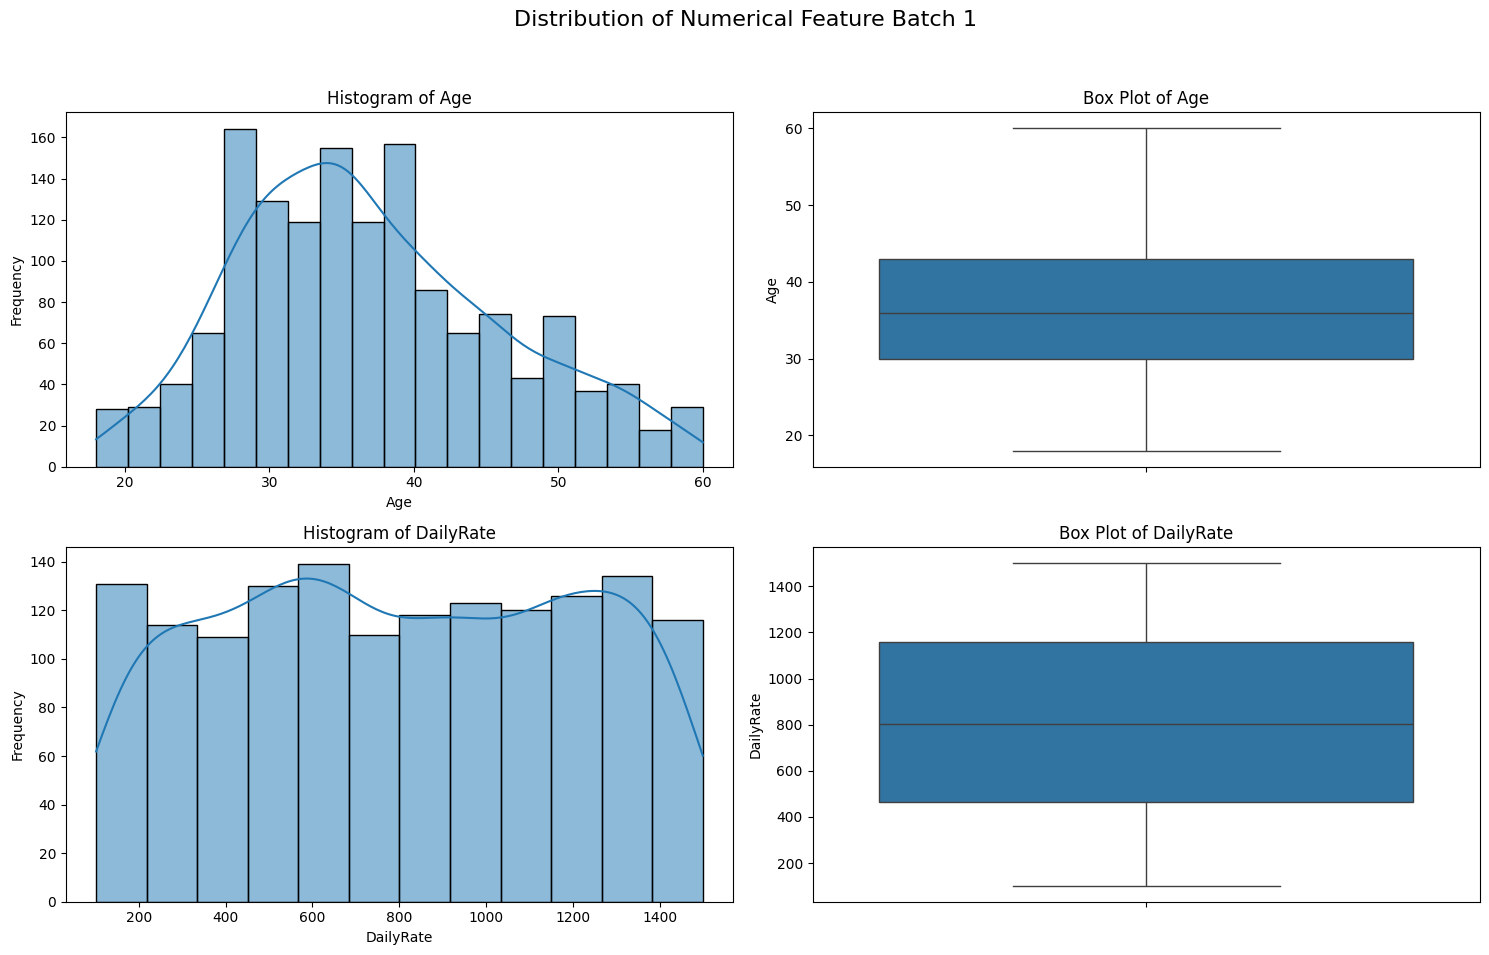

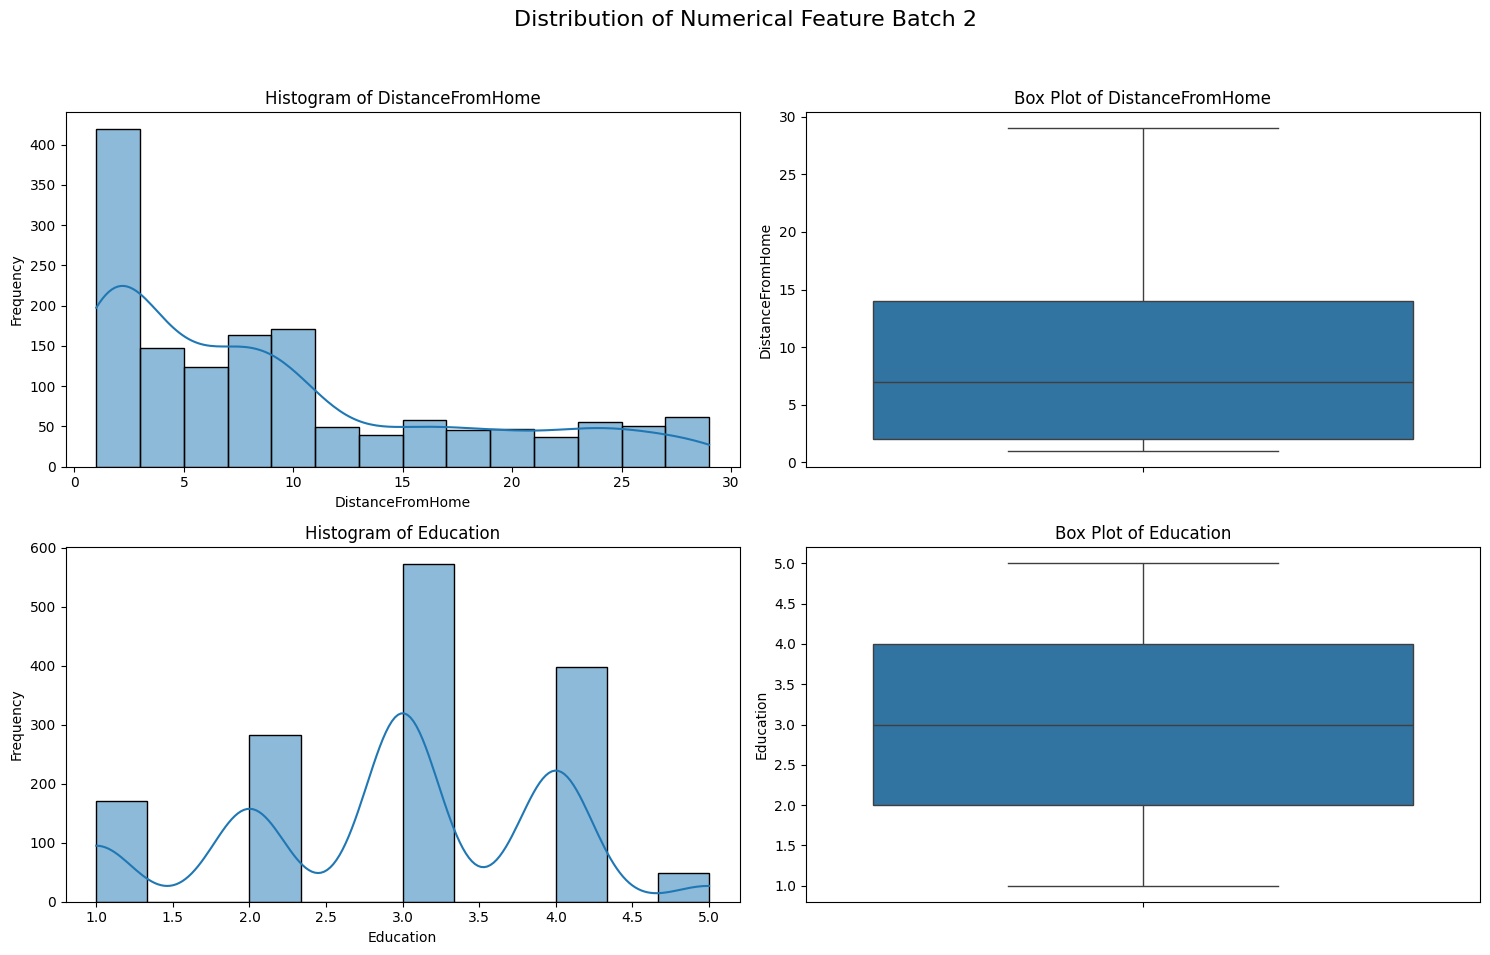

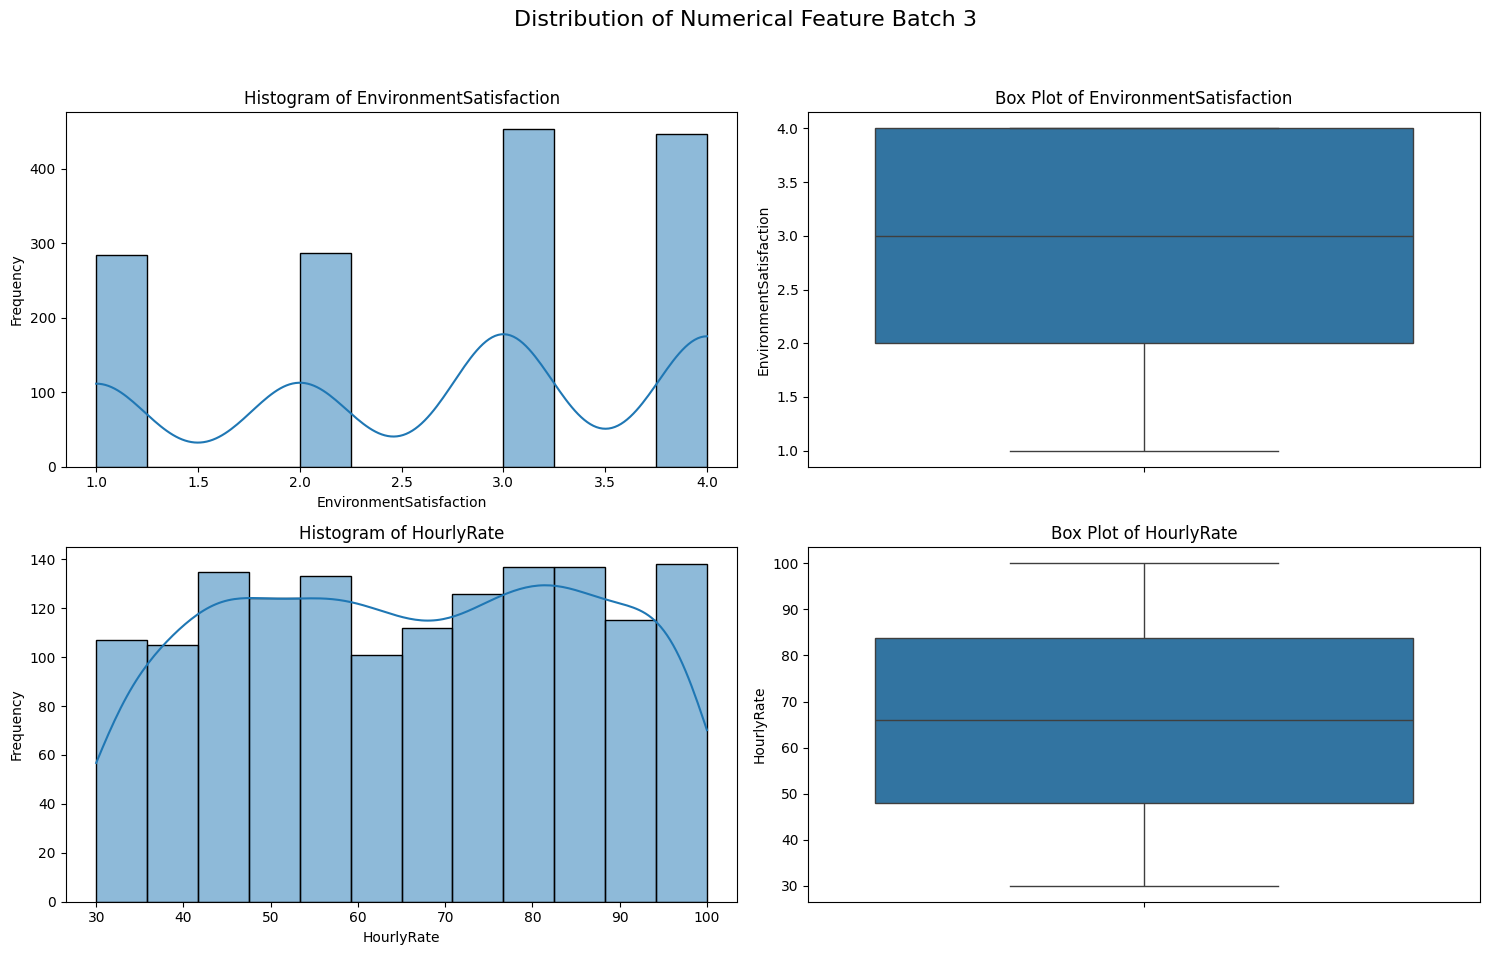

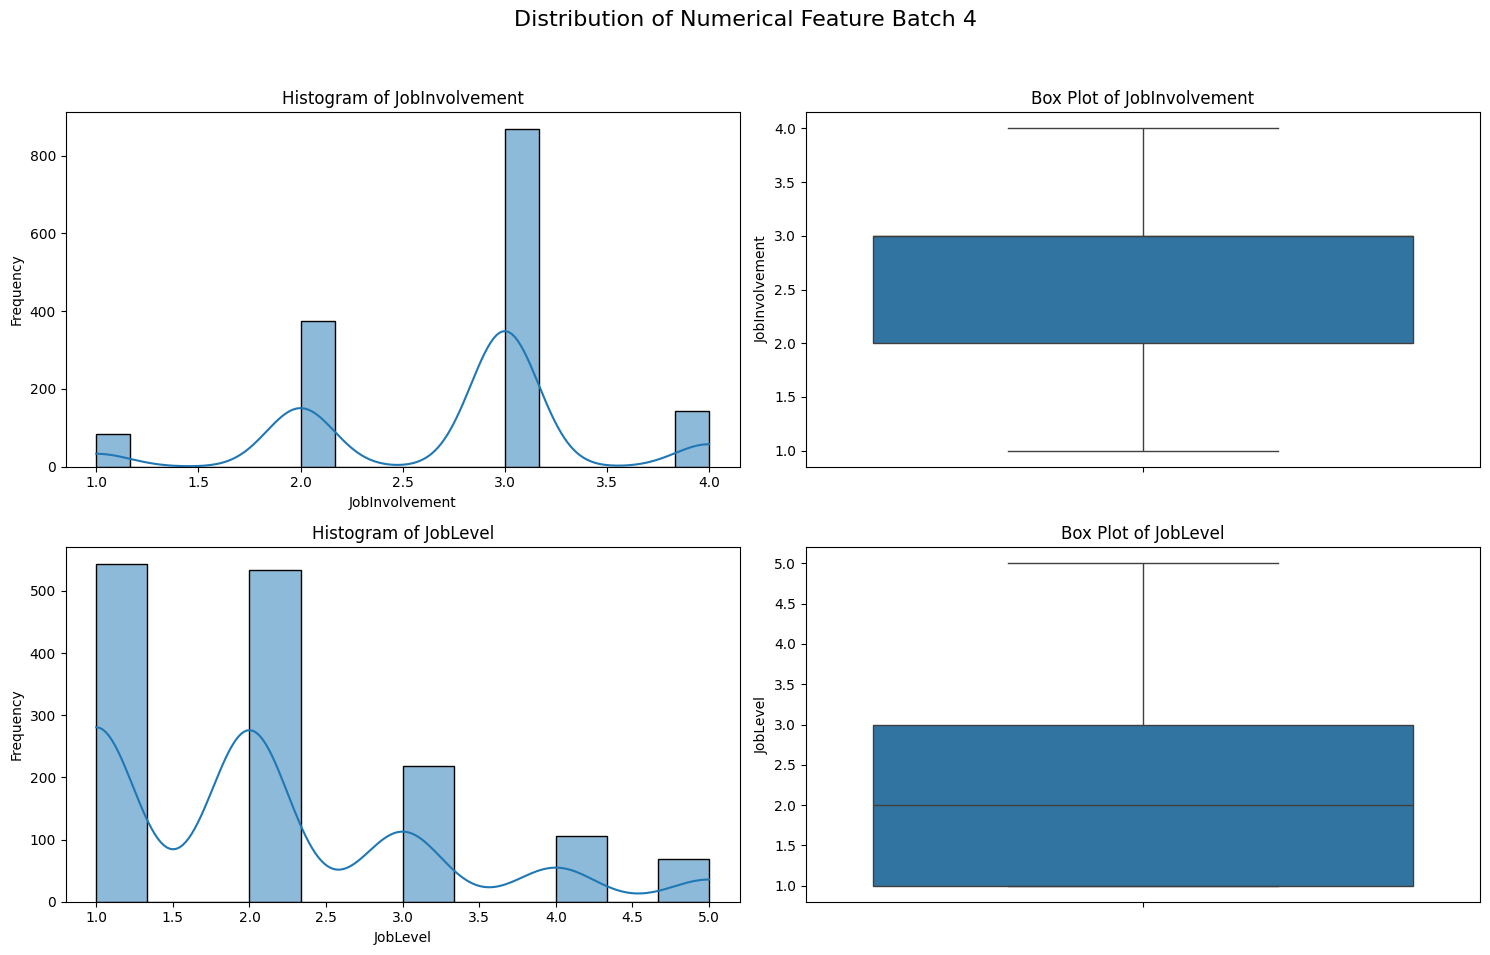

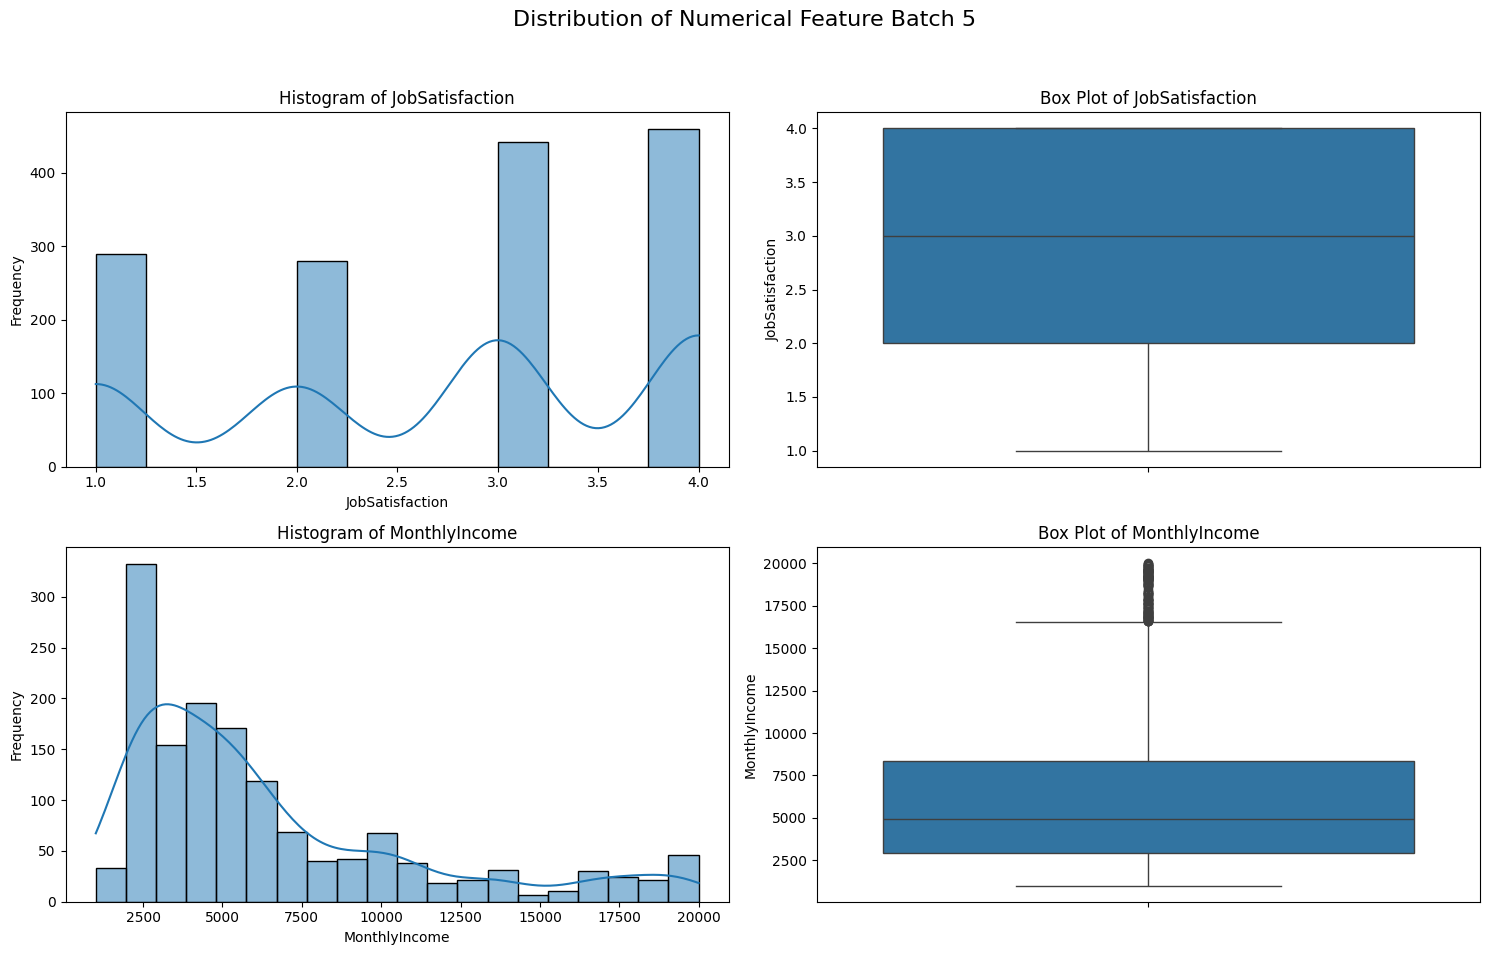

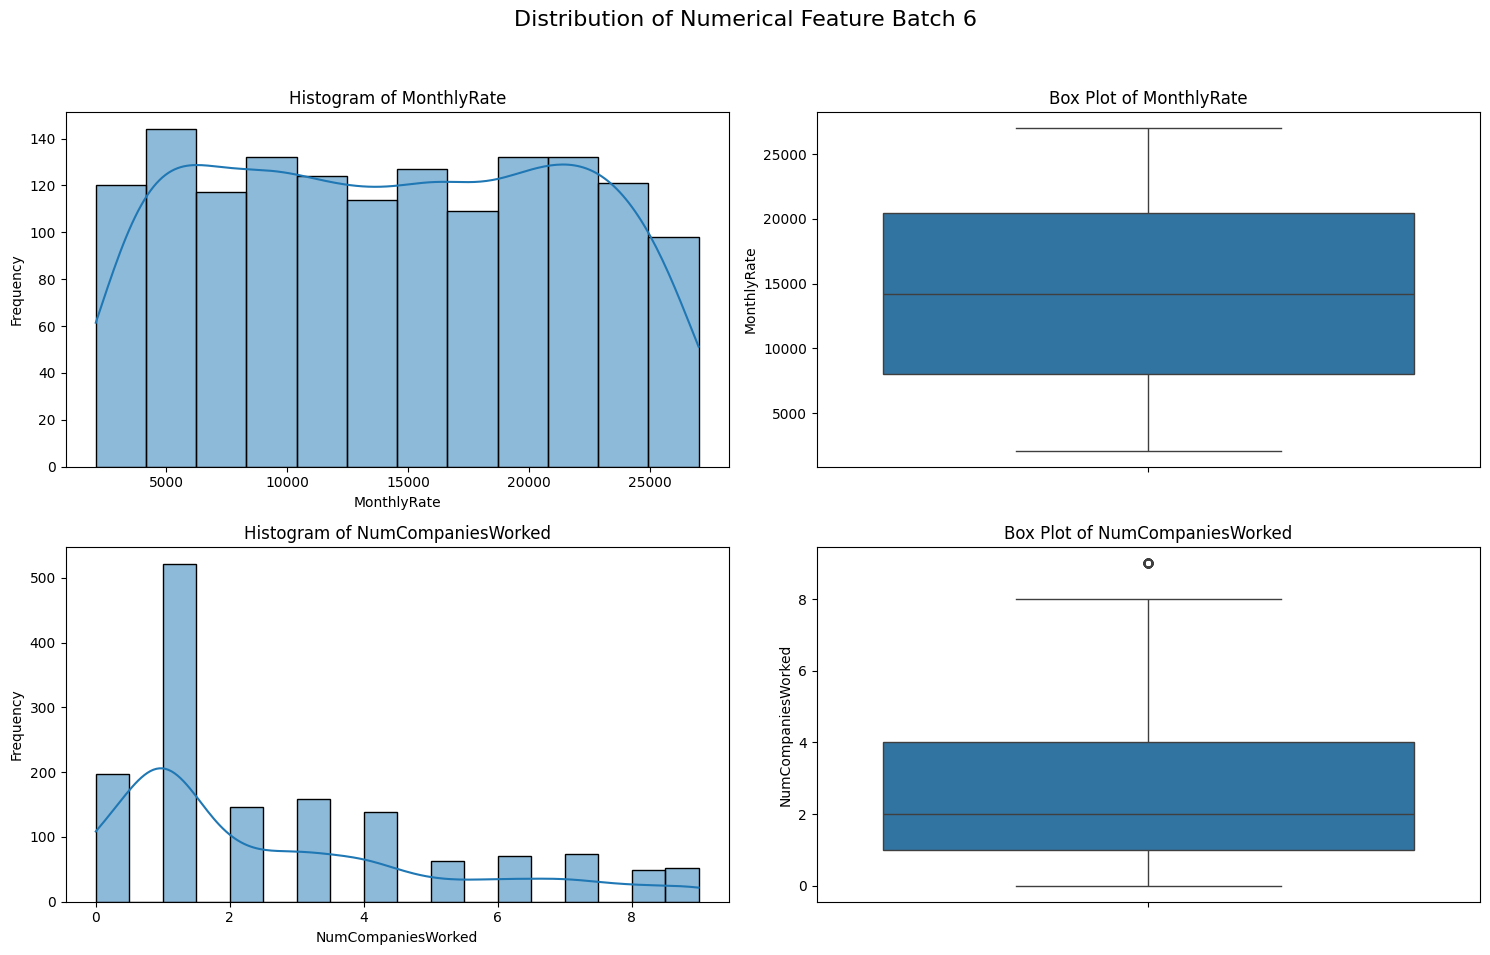

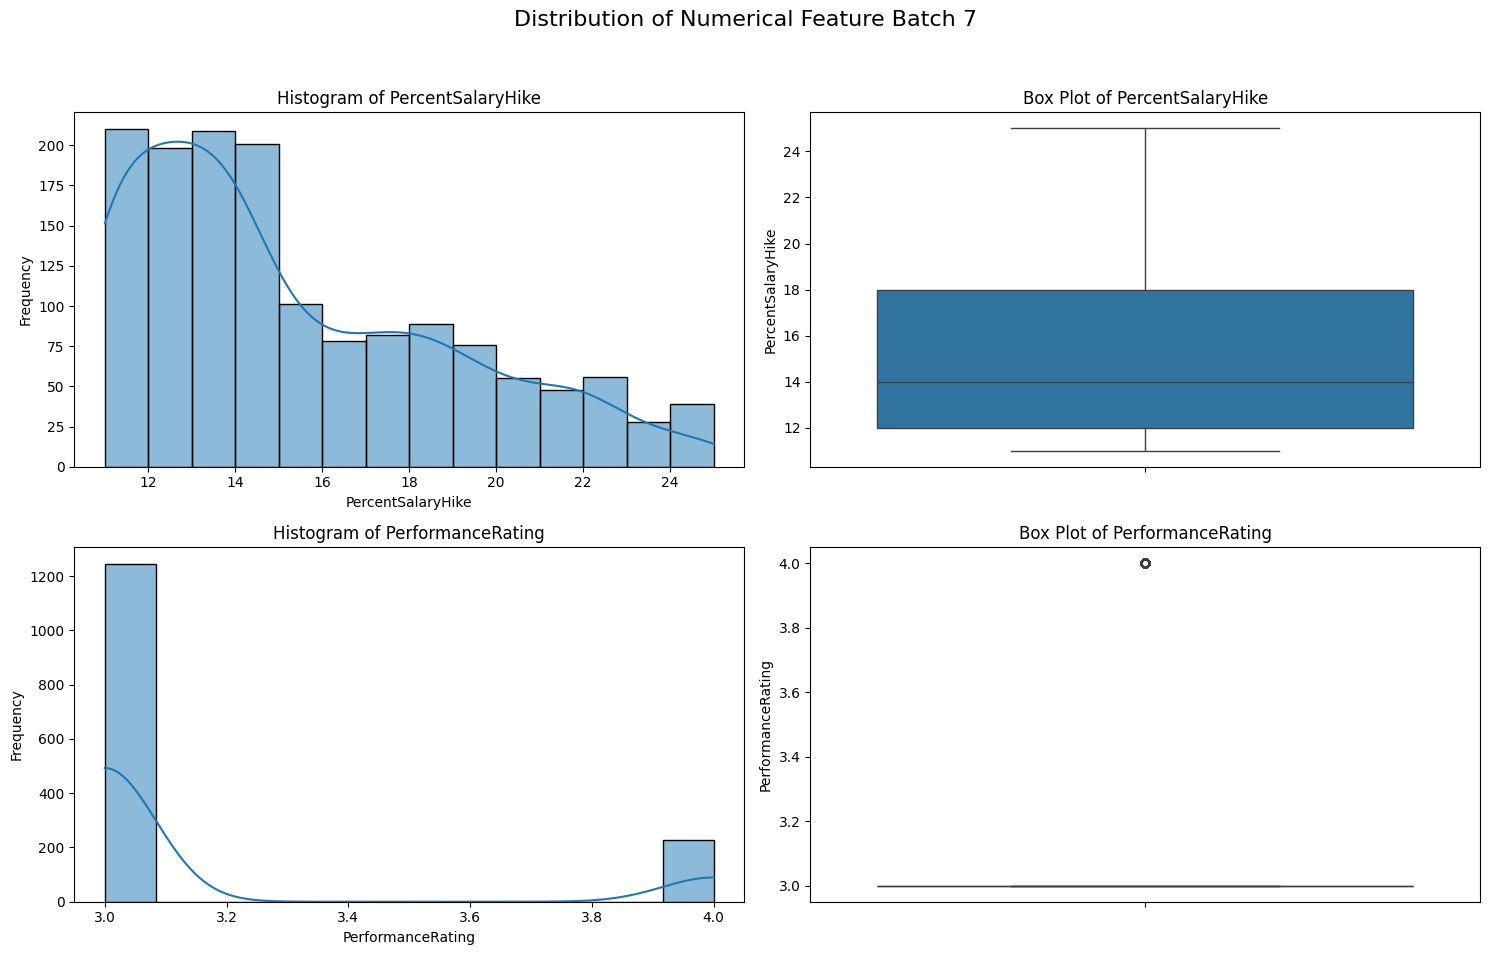

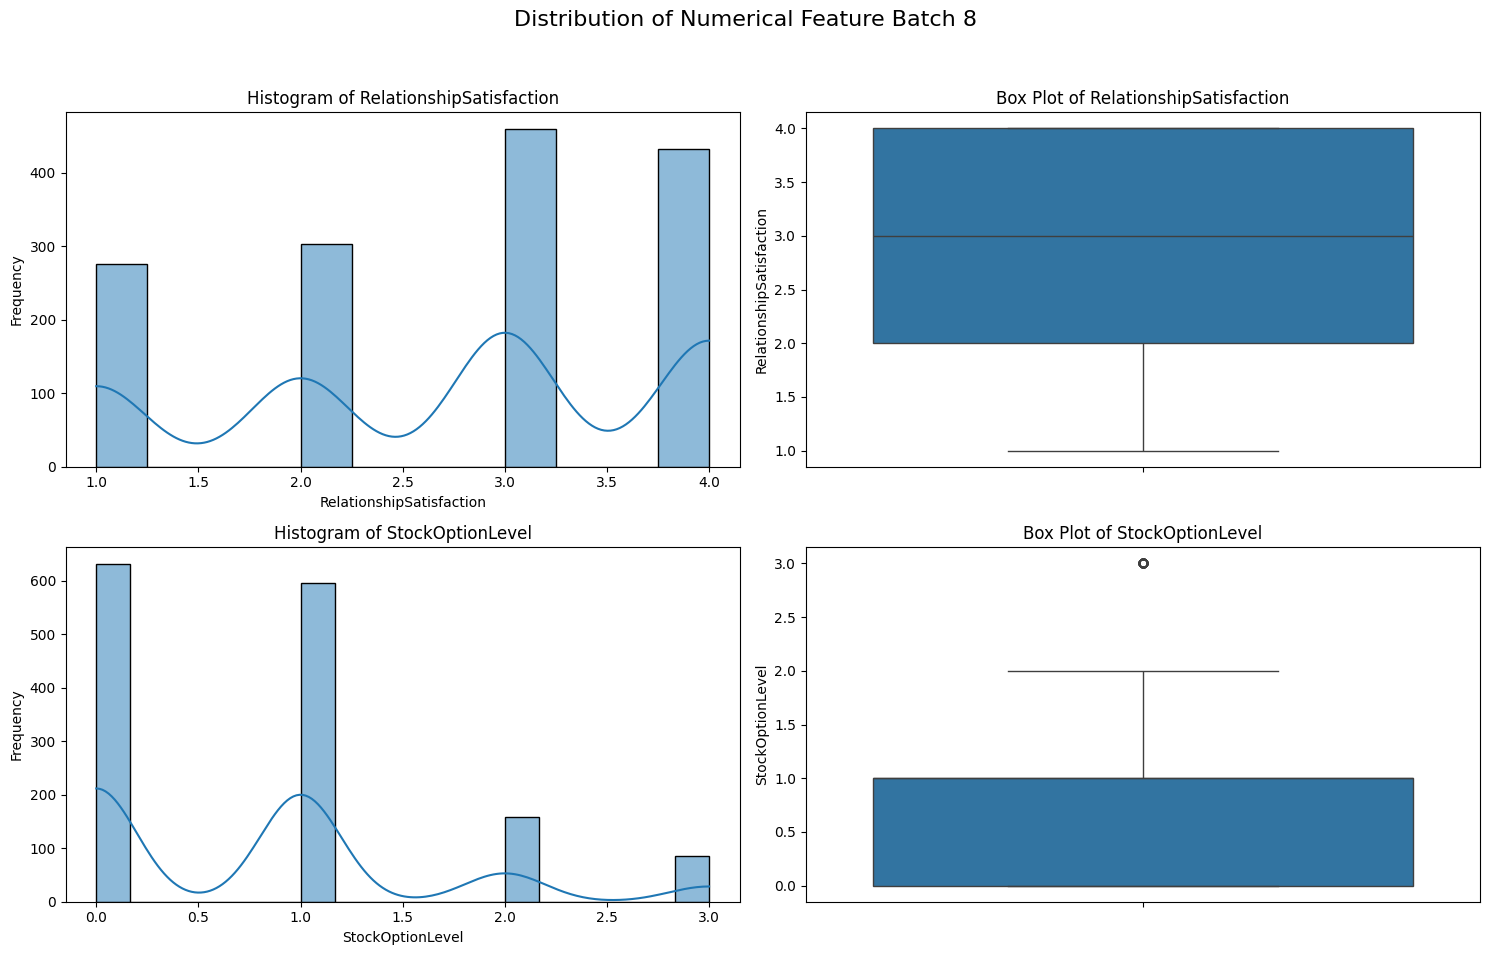

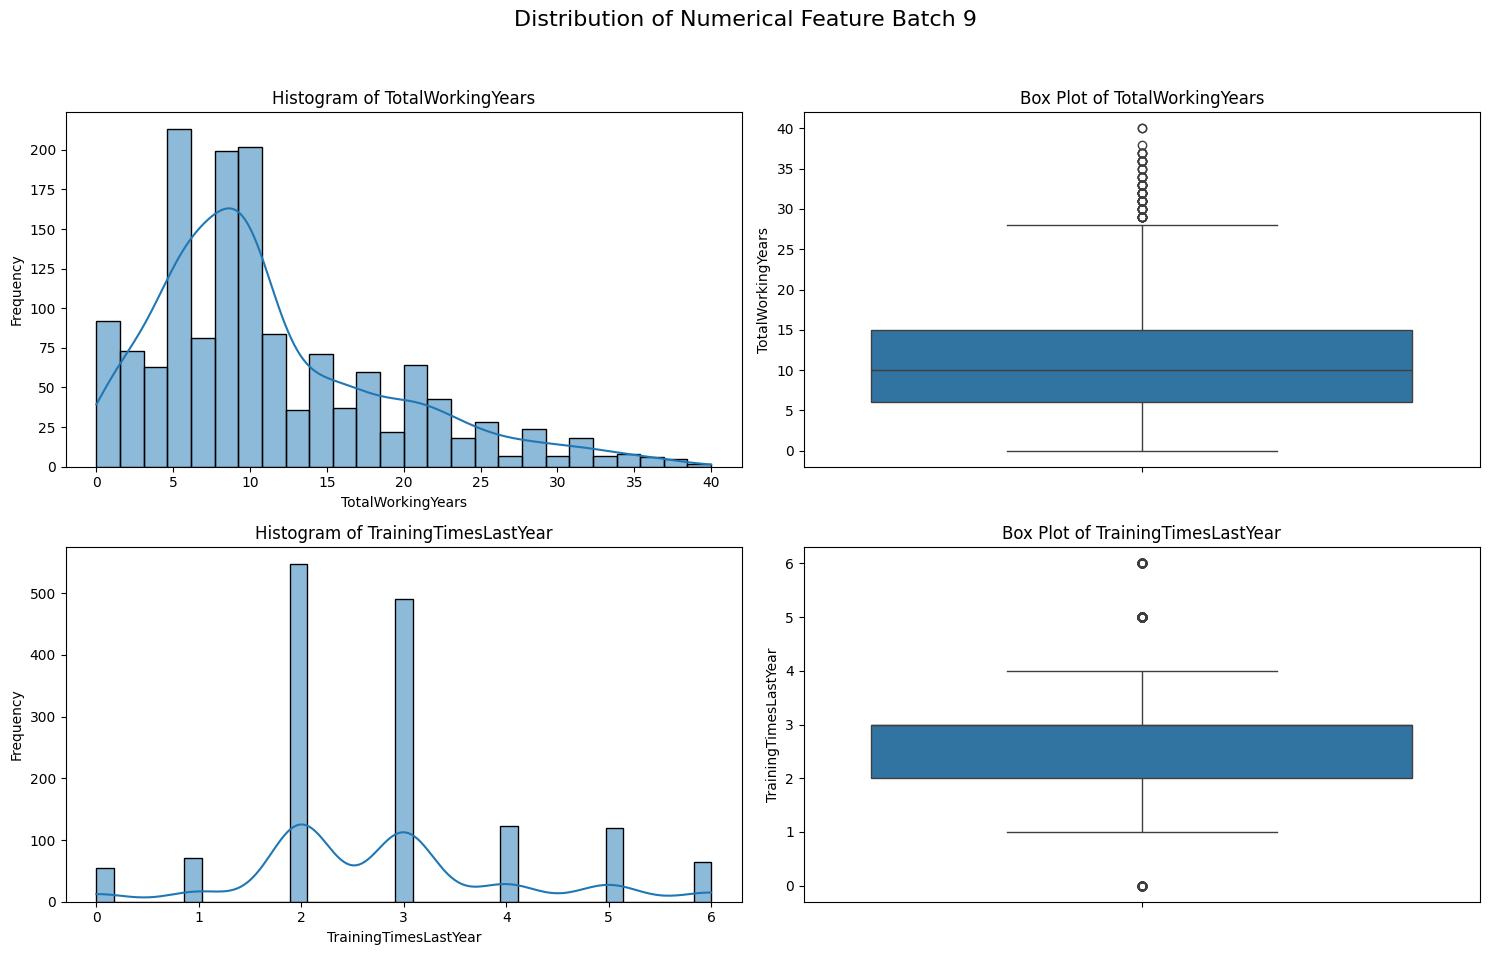

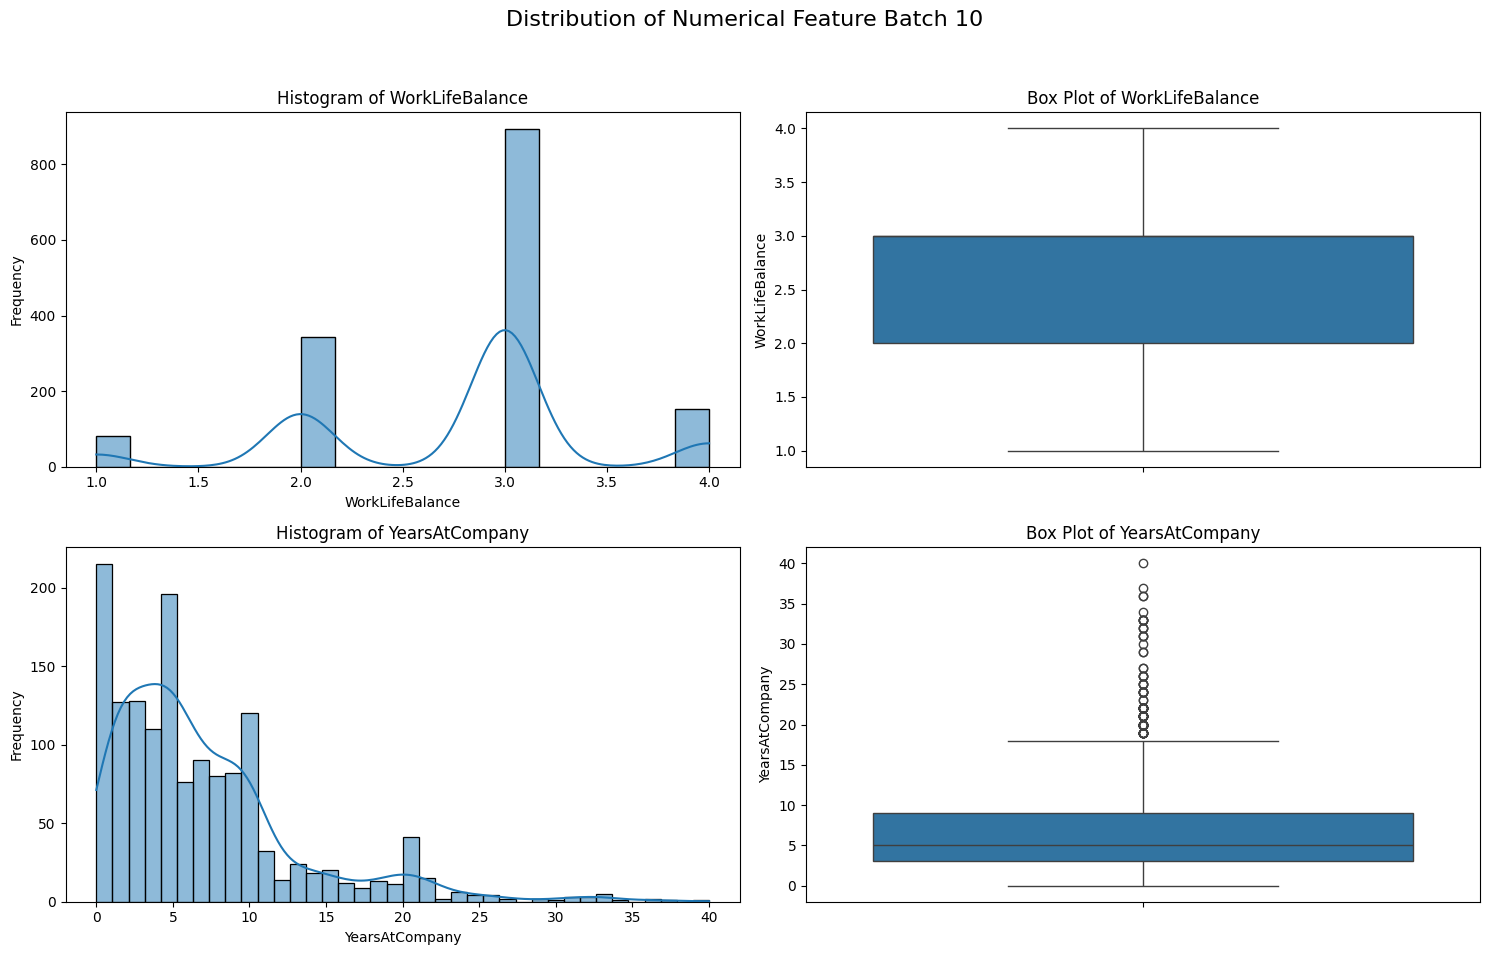

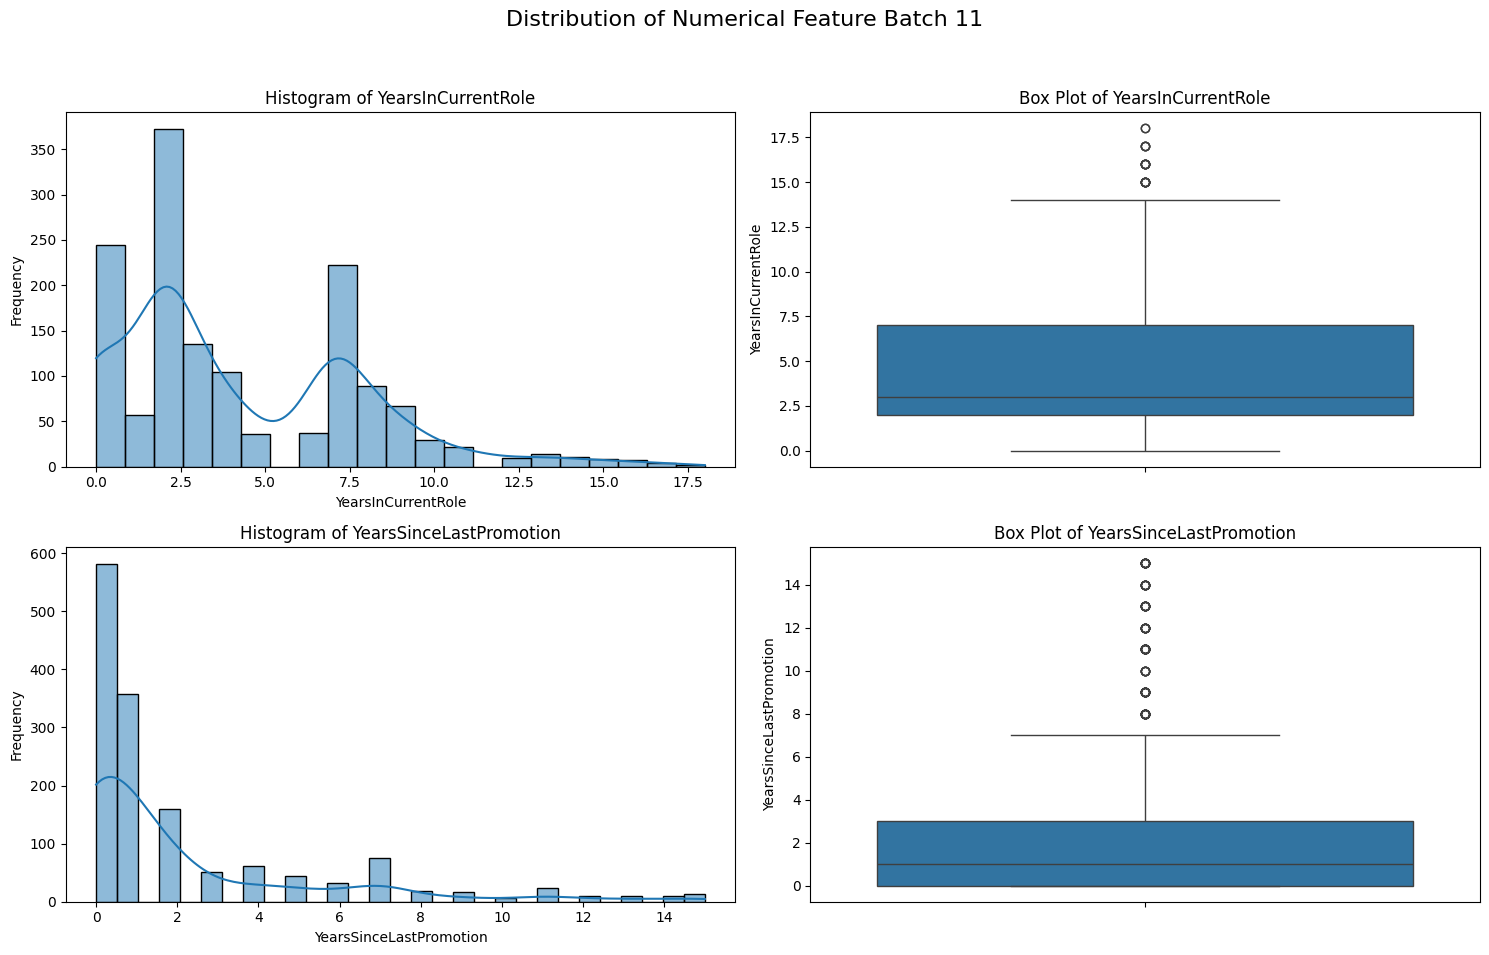

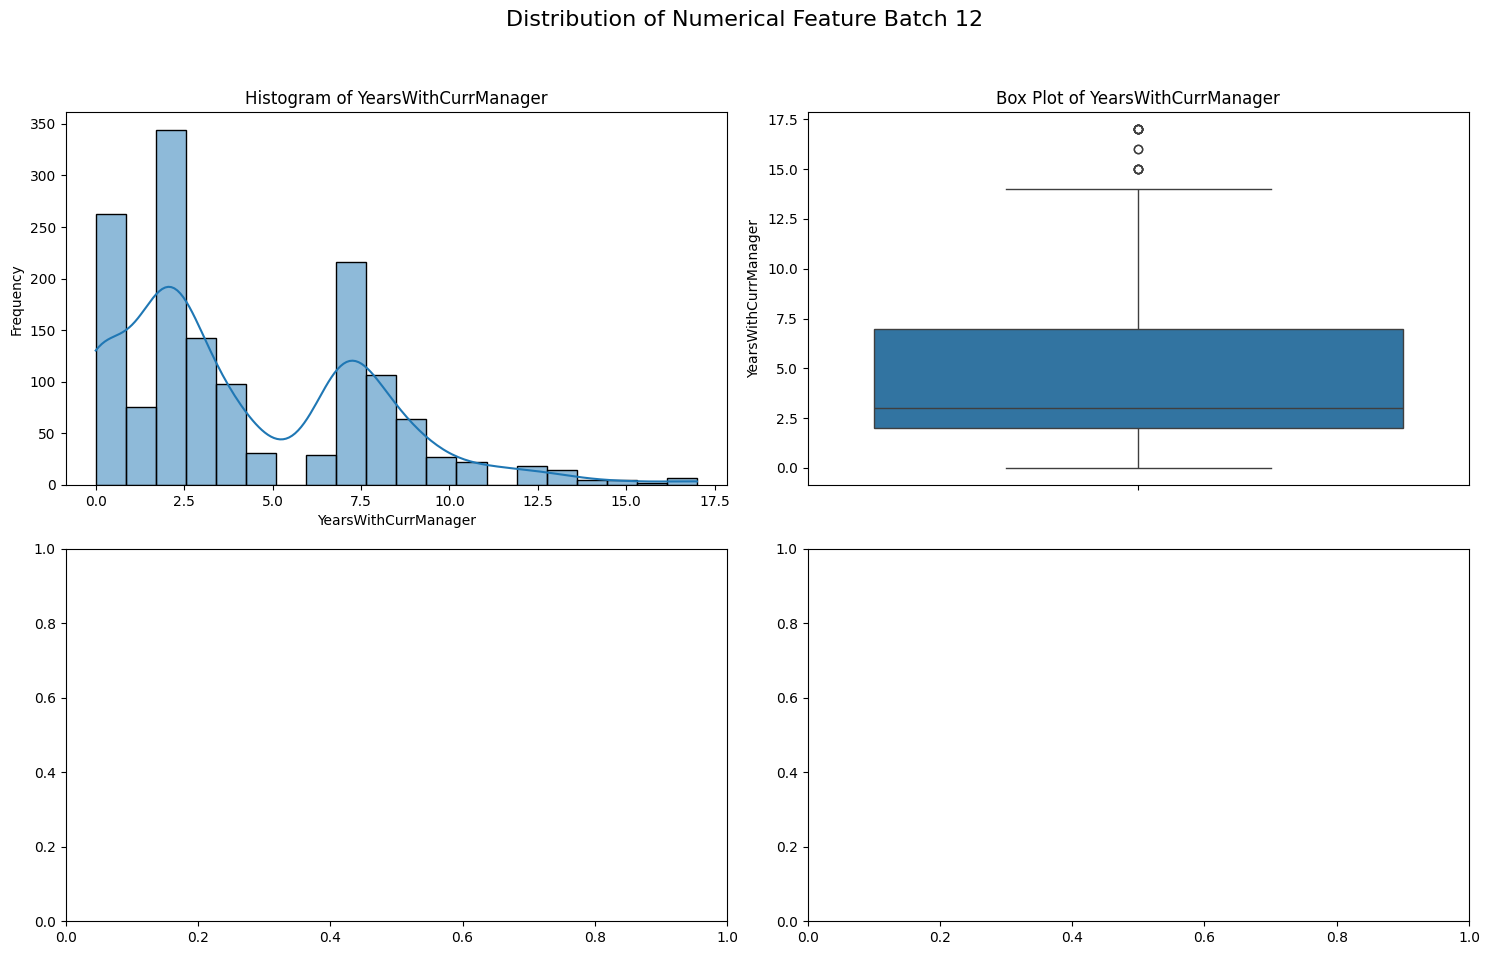

Histograms and box plots for numerical features have been generated.


In [10]:
numerical_cols = df_cleaned.select_dtypes(include=['int64']).columns

print(f"Identified {len(numerical_cols)} numerical columns for plotting:")
print(list(numerical_cols))

# Exclude 'Attrition' from numerical_cols if it's there as it's our target variable and already plotted
if 'Attrition' in numerical_cols:
    numerical_cols = numerical_cols.drop('Attrition')

# Define how many features to plot per figure (each feature will have a hist and a box plot)
features_per_figure = 2 # This means 2 features, or 4 total plots (2 hists + 2 boxplots) per figure
current_figure = None

for i, col in enumerate(numerical_cols):
    # Create a new figure for every `features_per_figure` features
    if i % features_per_figure == 0:
        # If not the first figure, close the previous one
        if current_figure is not None:
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

        # Create a new figure with `features_per_figure` rows and 2 columns (one for hist, one for box plot)
        fig, axes = plt.subplots(nrows=features_per_figure, ncols=2, figsize=(15, 5 * features_per_figure))
        fig.suptitle(f'Distribution of Numerical Feature Batch {int(i / features_per_figure) + 1}', fontsize=16)
        axes = axes.flatten() # Flatten the axes array for easier indexing
        current_figure = fig # Keep track of the current figure

    # Calculate indices for histogram and box plot within the flattened axes array
    # For feature `i`, its plots will be at `(i % features_per_figure) * 2` and `(i % features_per_figure) * 2 + 1`
    ax_offset = (i % features_per_figure) * 2
    hist_ax = axes[ax_offset]
    box_ax = axes[ax_offset + 1]

    # Plot Histogram
    sns.histplot(df_cleaned[col], kde=True, ax=hist_ax)
    hist_ax.set_title(f'Histogram of {col}')
    hist_ax.set_xlabel(col)
    hist_ax.set_ylabel('Frequency')

    # Plot Box Plot
    sns.boxplot(y=df_cleaned[col], ax=box_ax)
    box_ax.set_title(f'Box Plot of {col}')
    box_ax.set_ylabel(col)

# Display the last figure if there are any remaining plots
if current_figure is not None:
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Histograms and box plots for numerical features have been generated.")

Identified 24 numerical columns for plotting:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


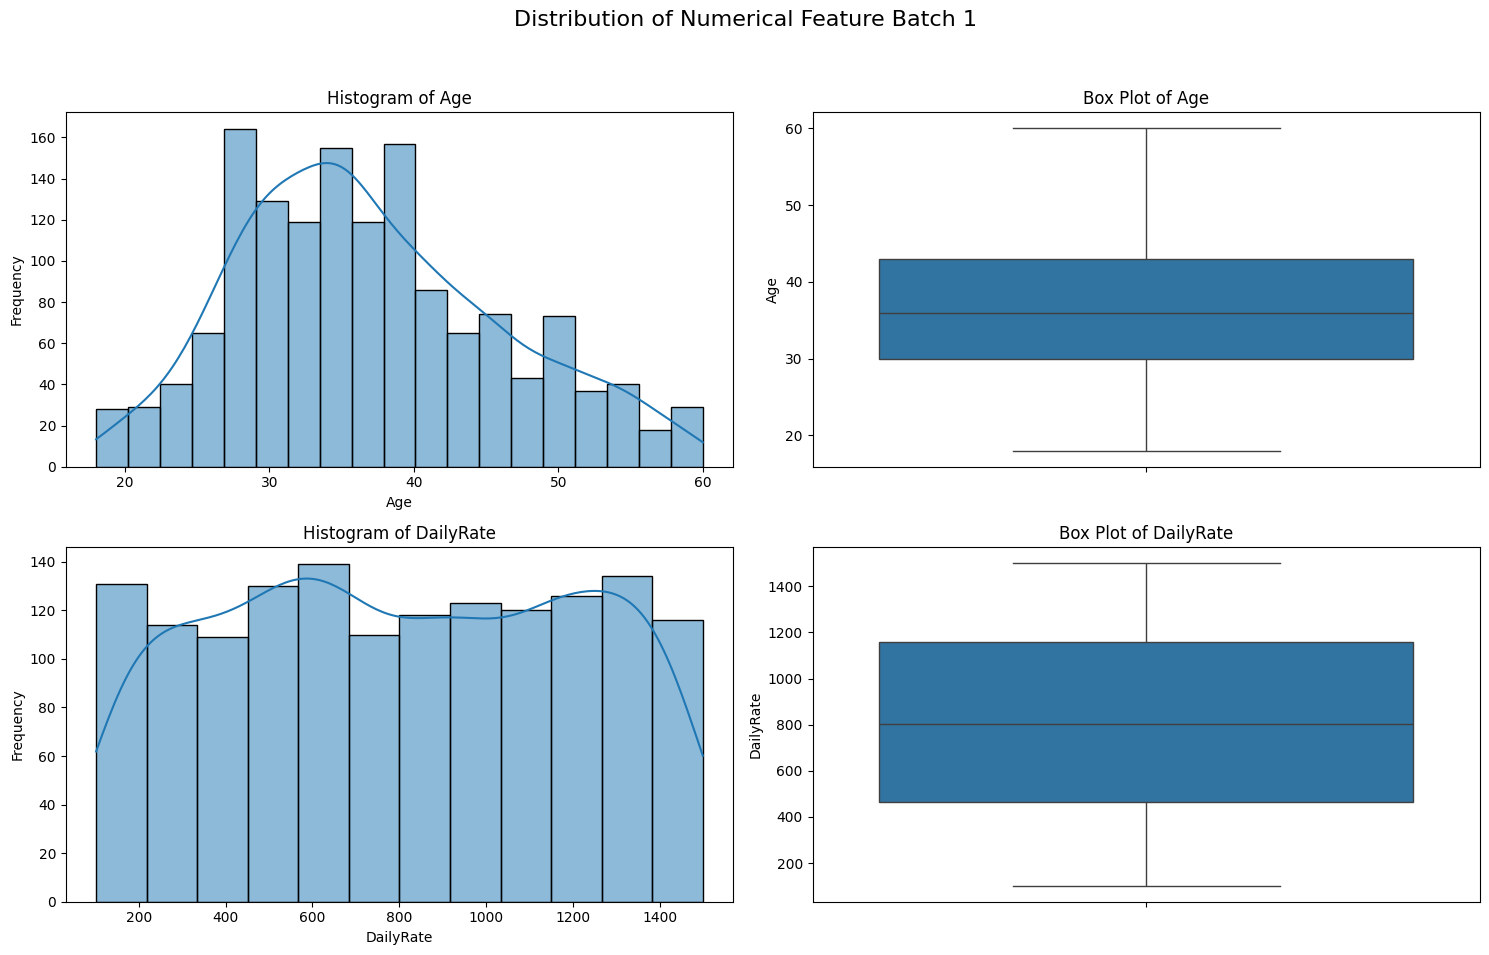

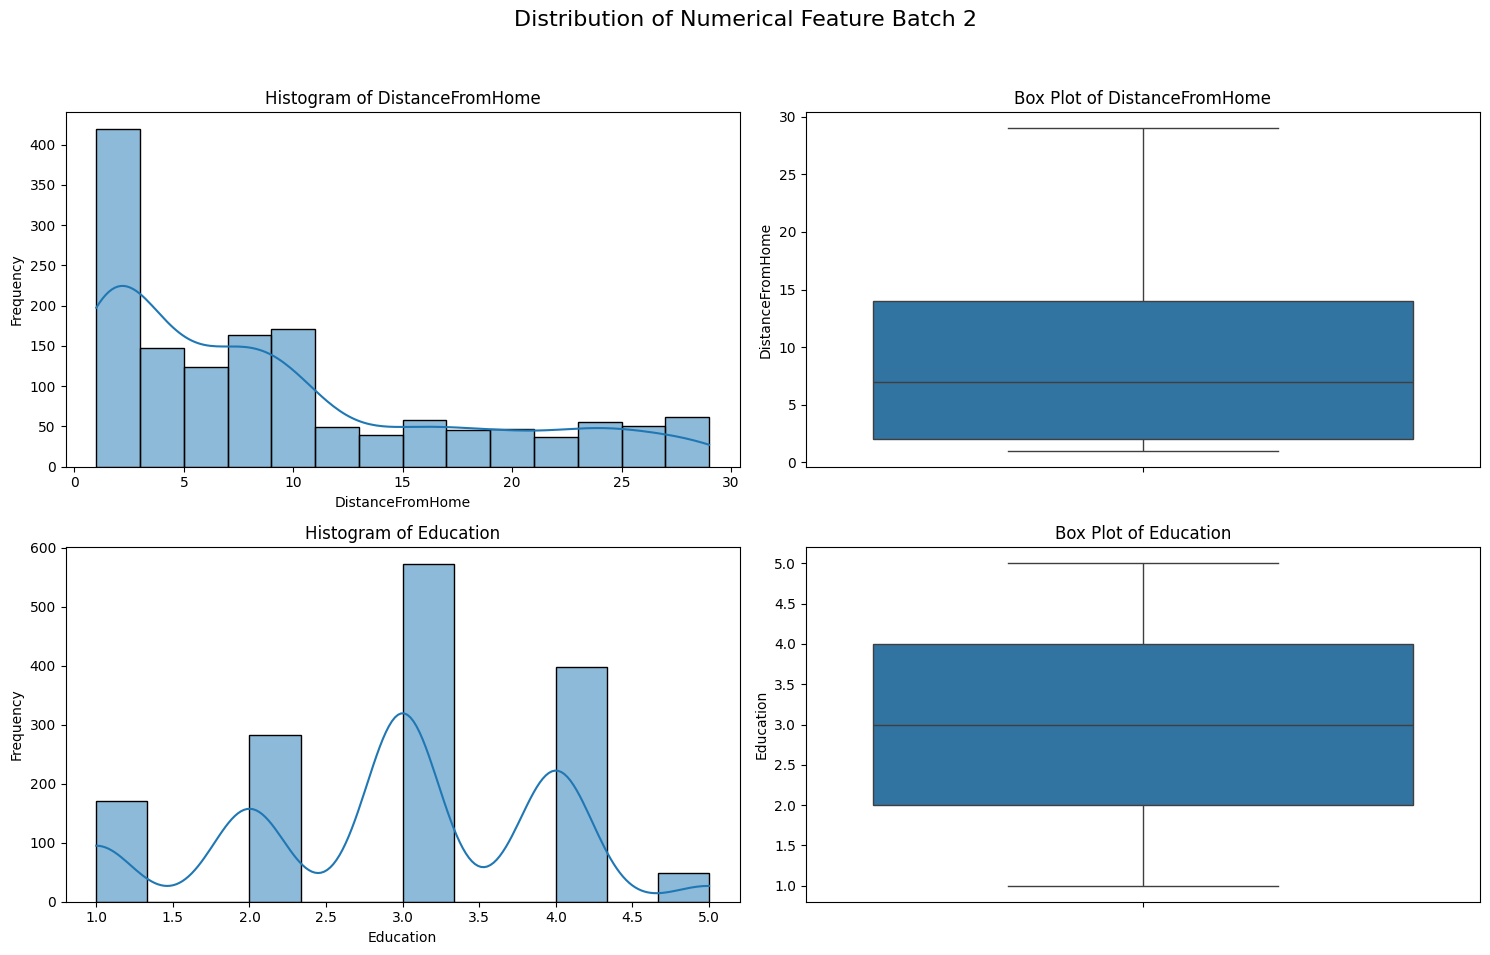

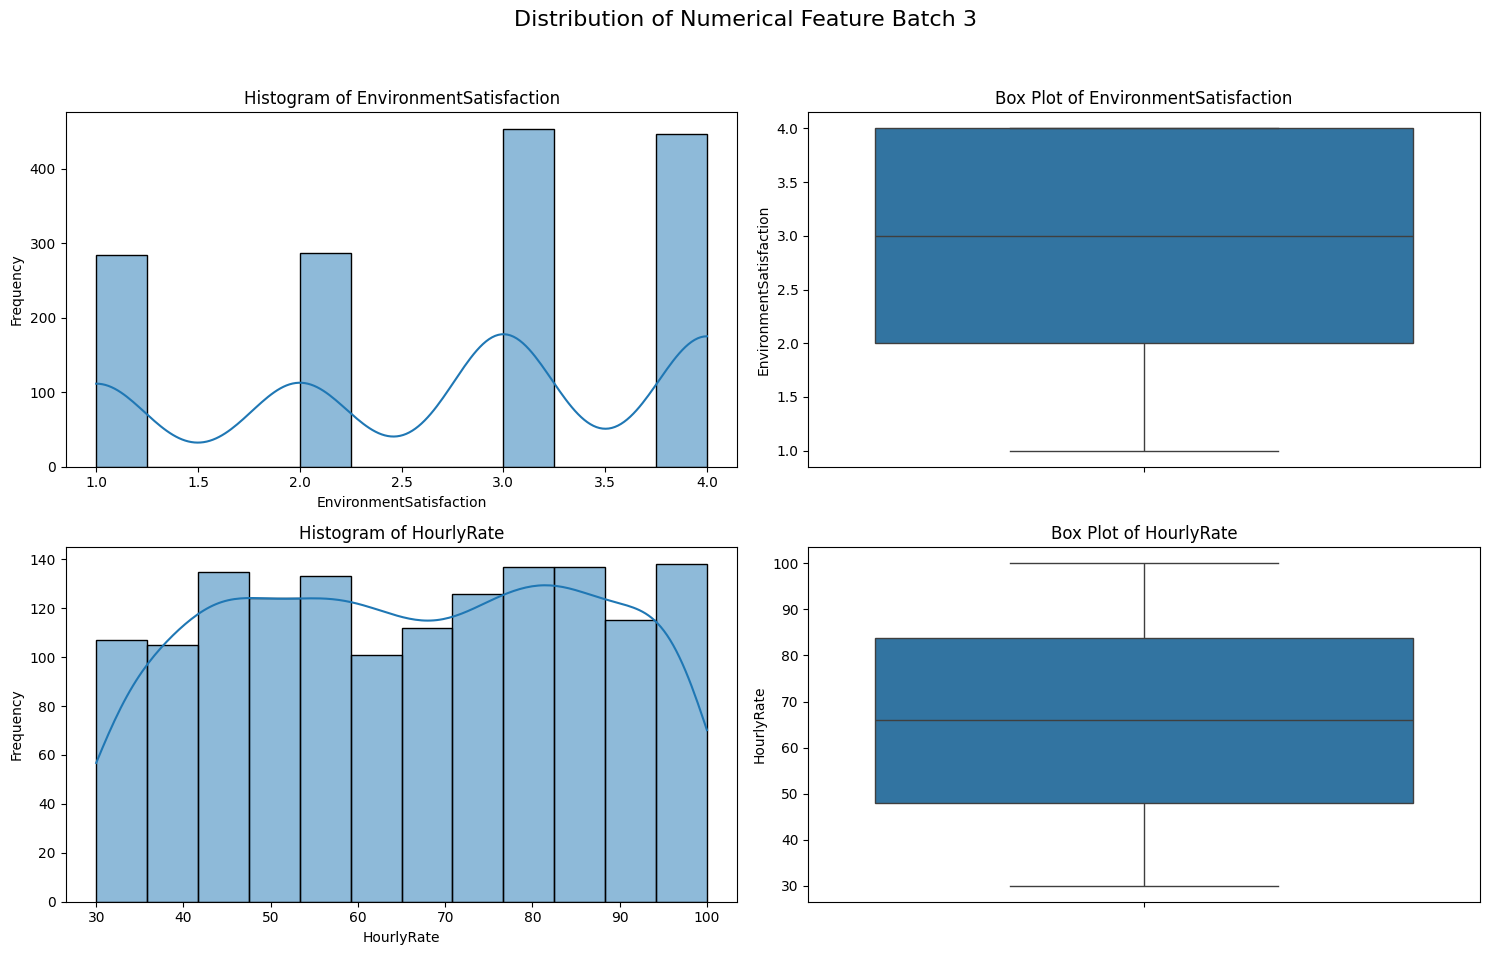

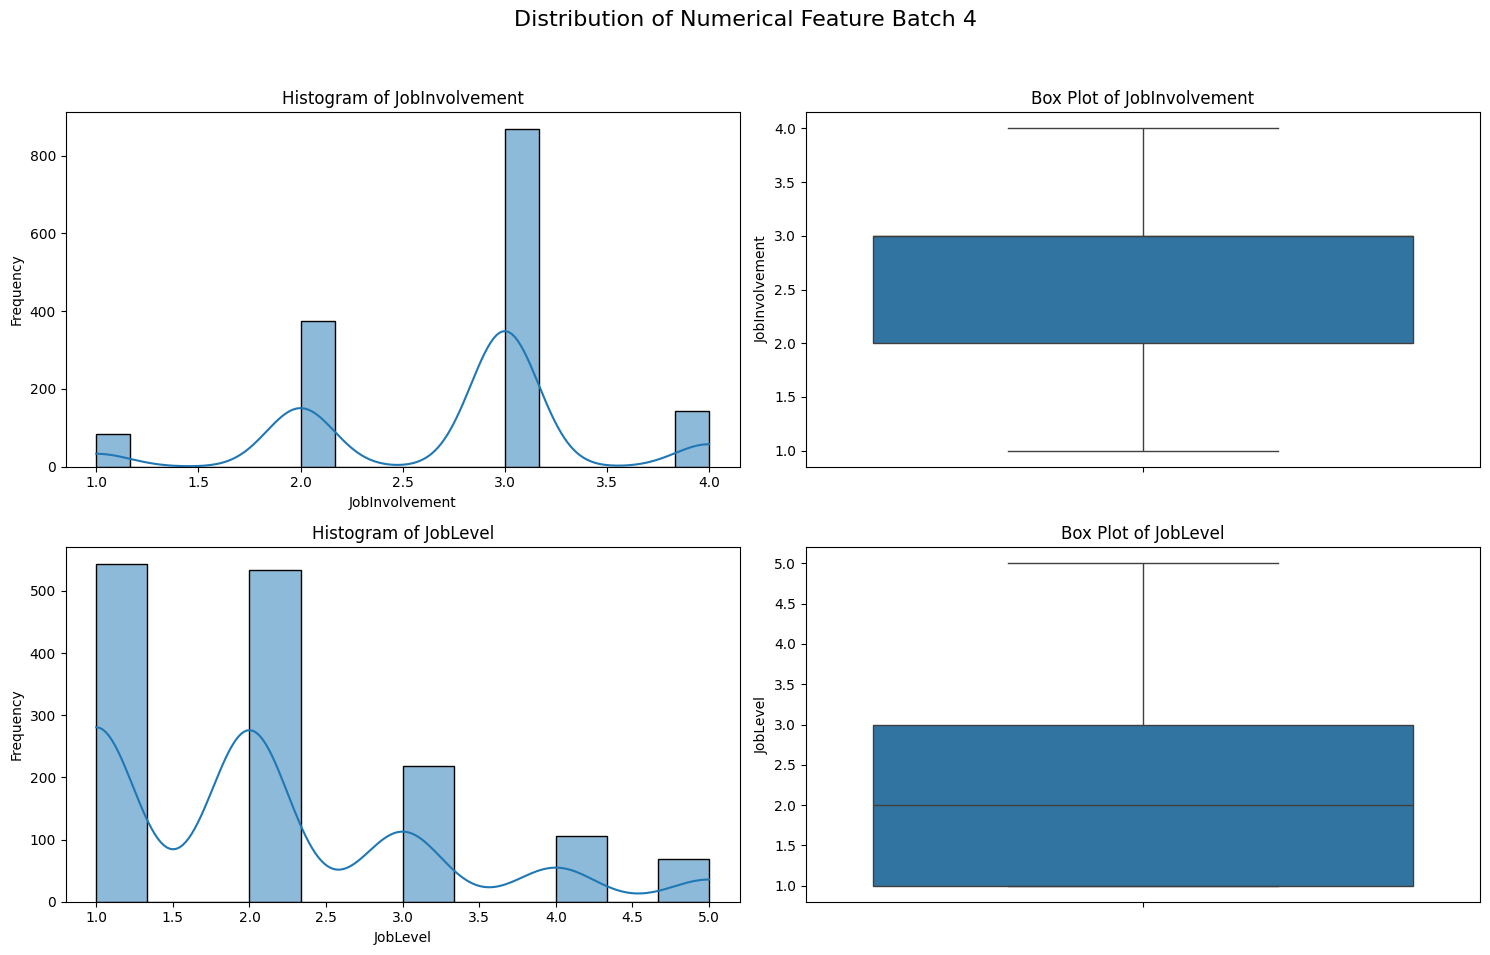

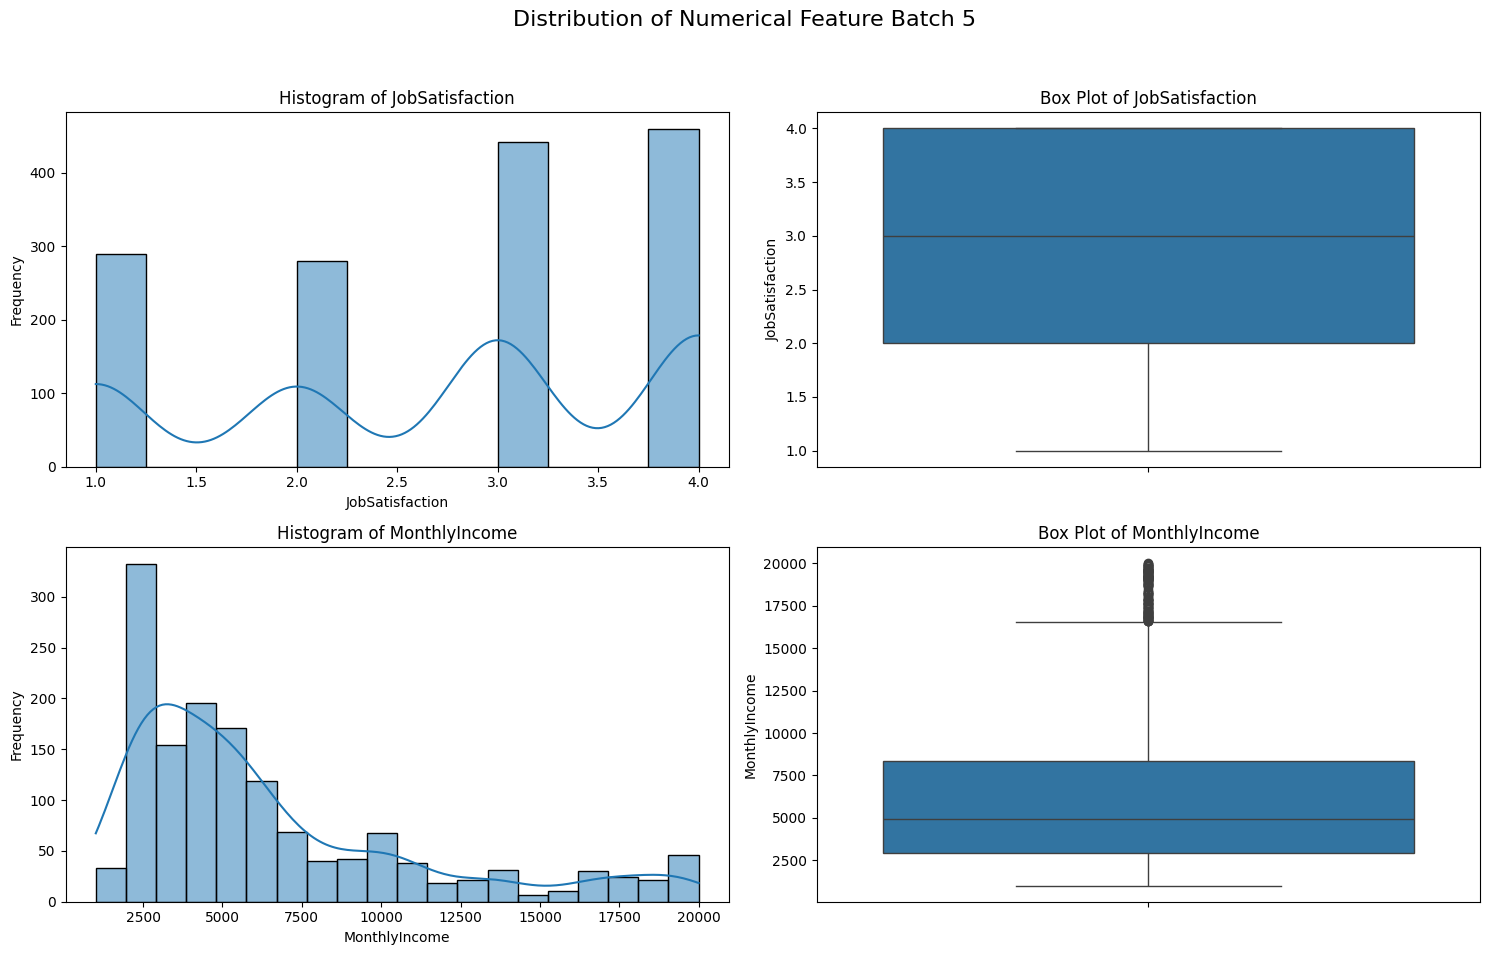

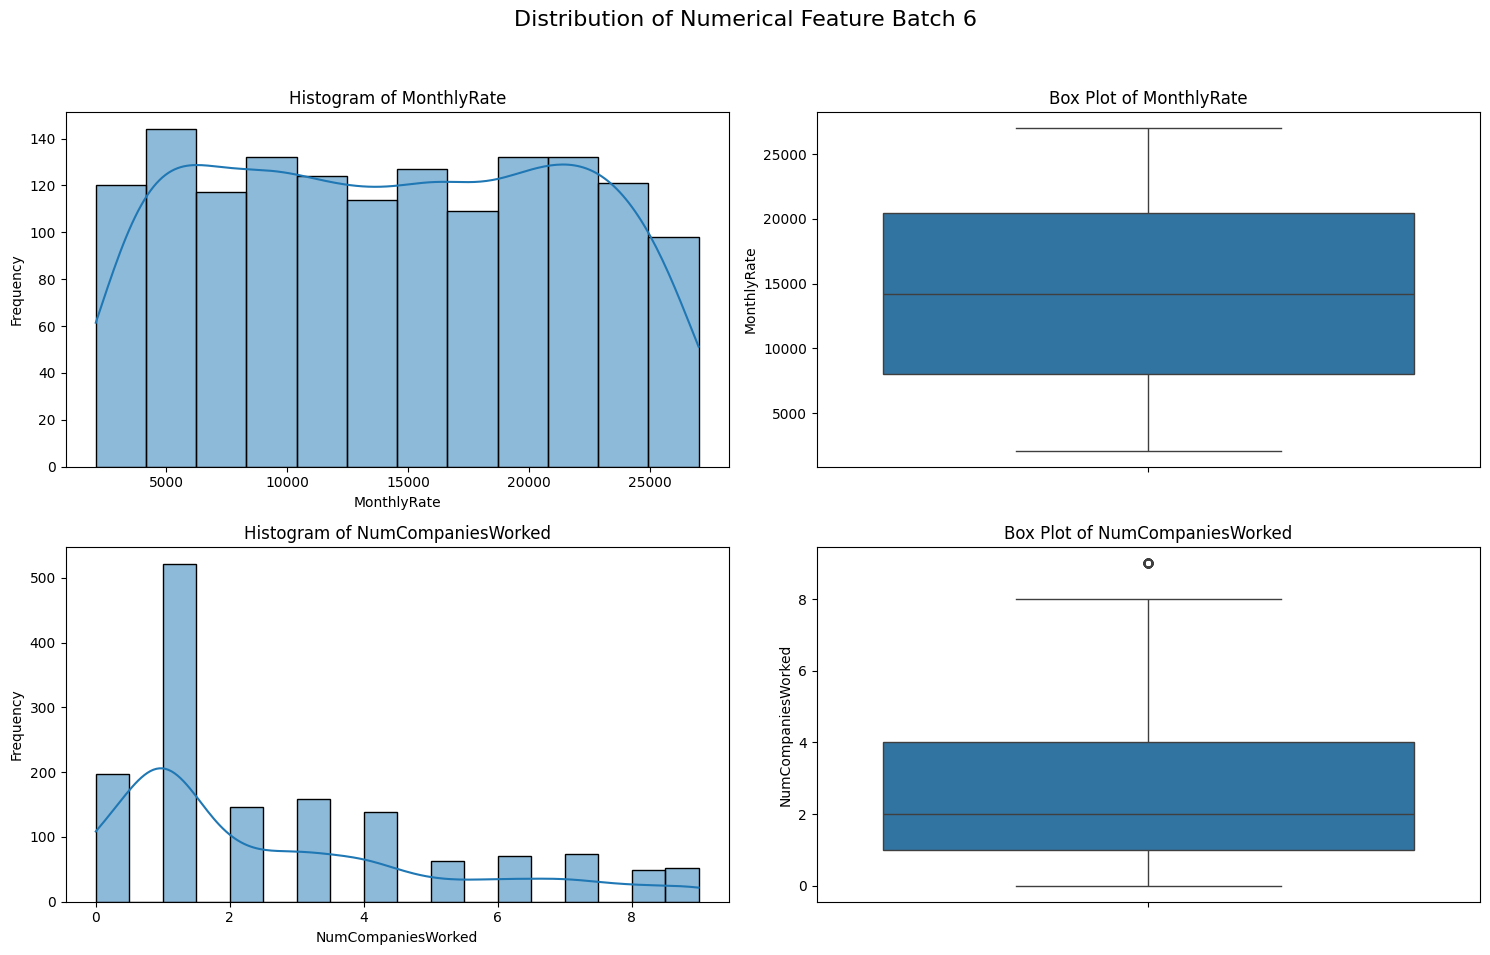

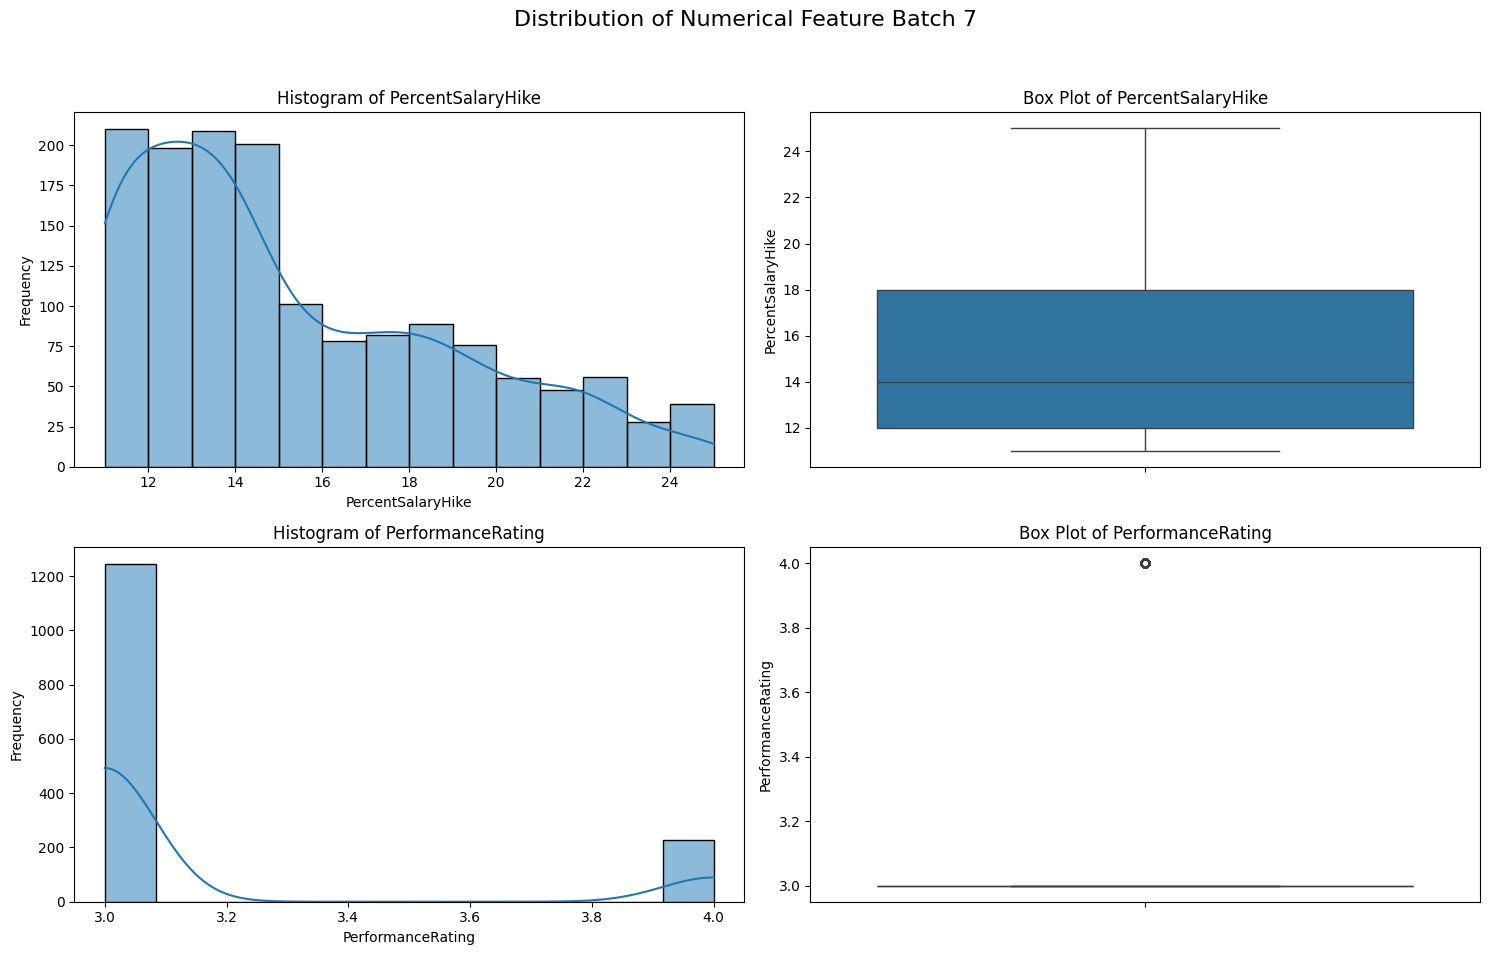

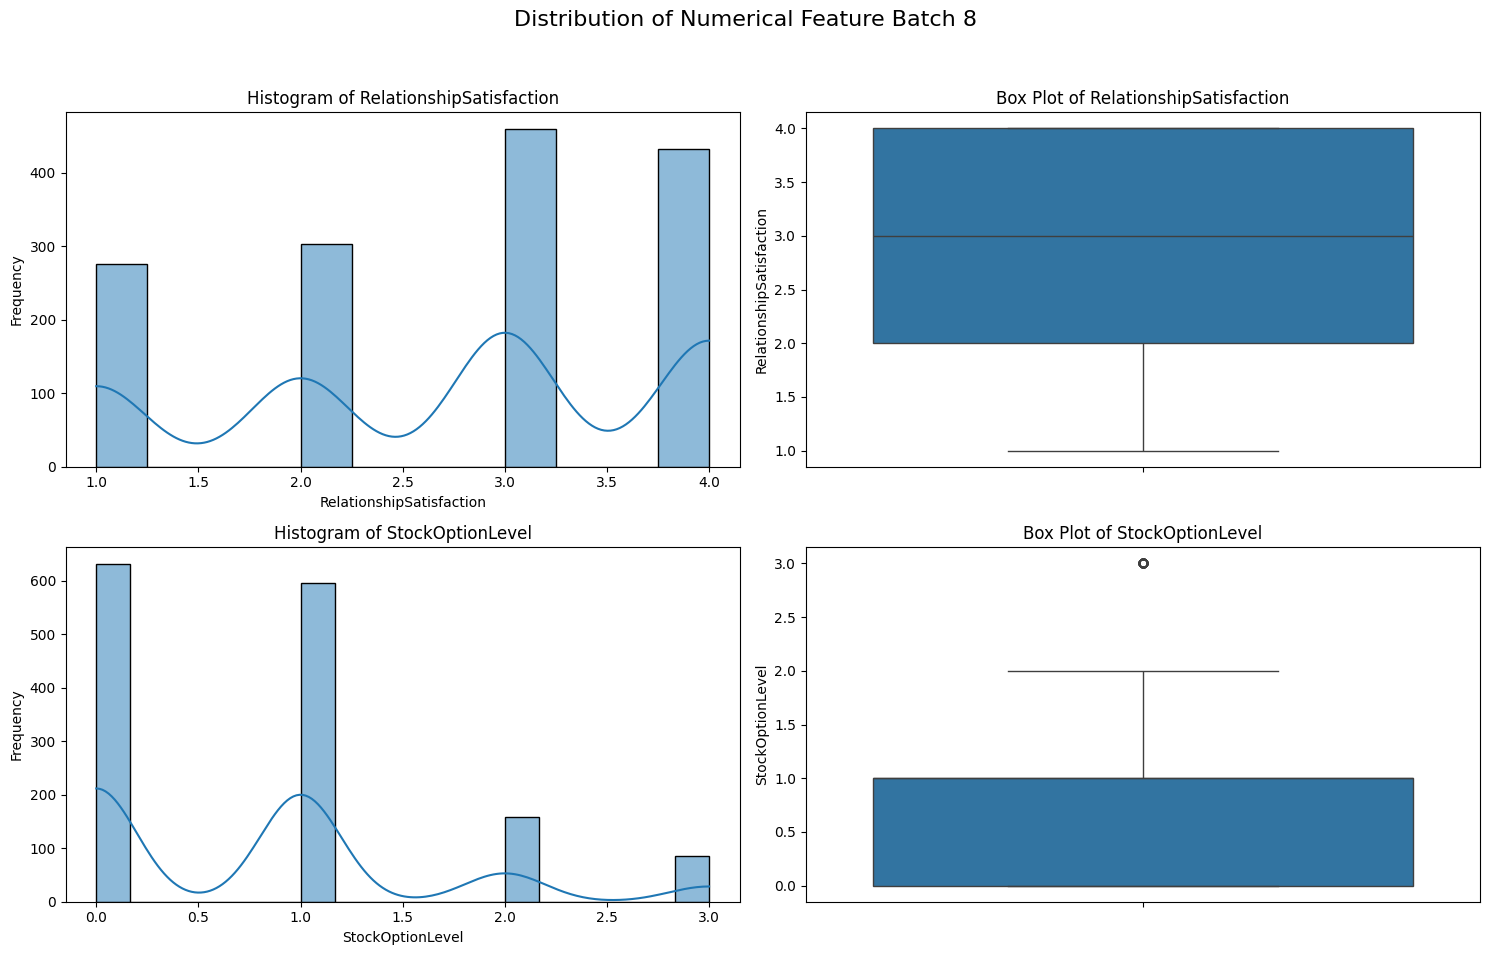

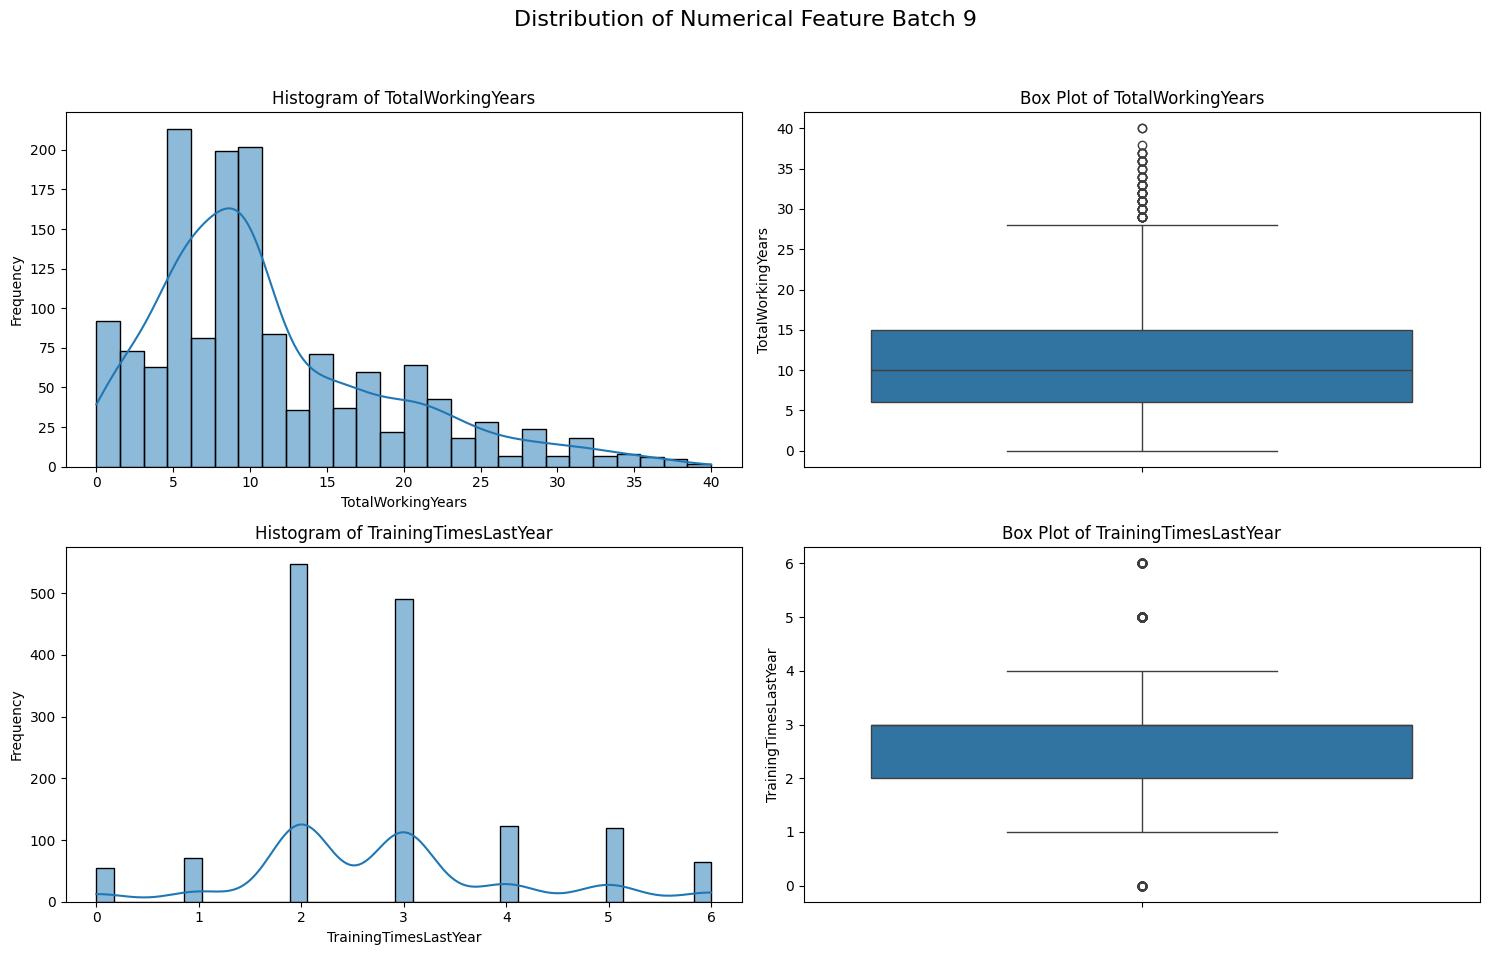

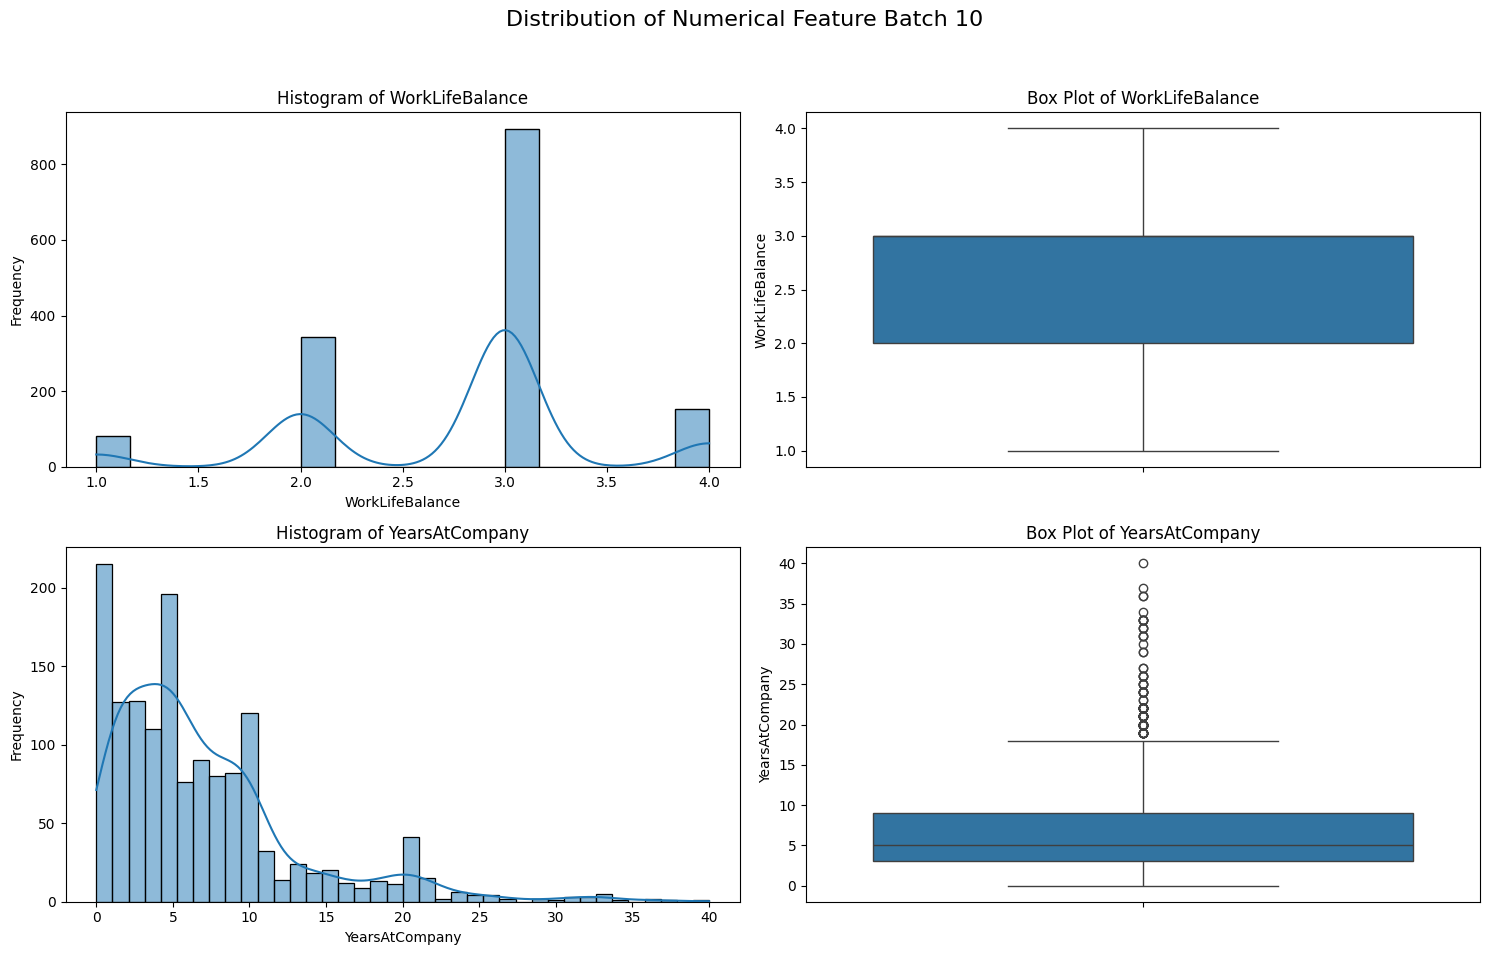

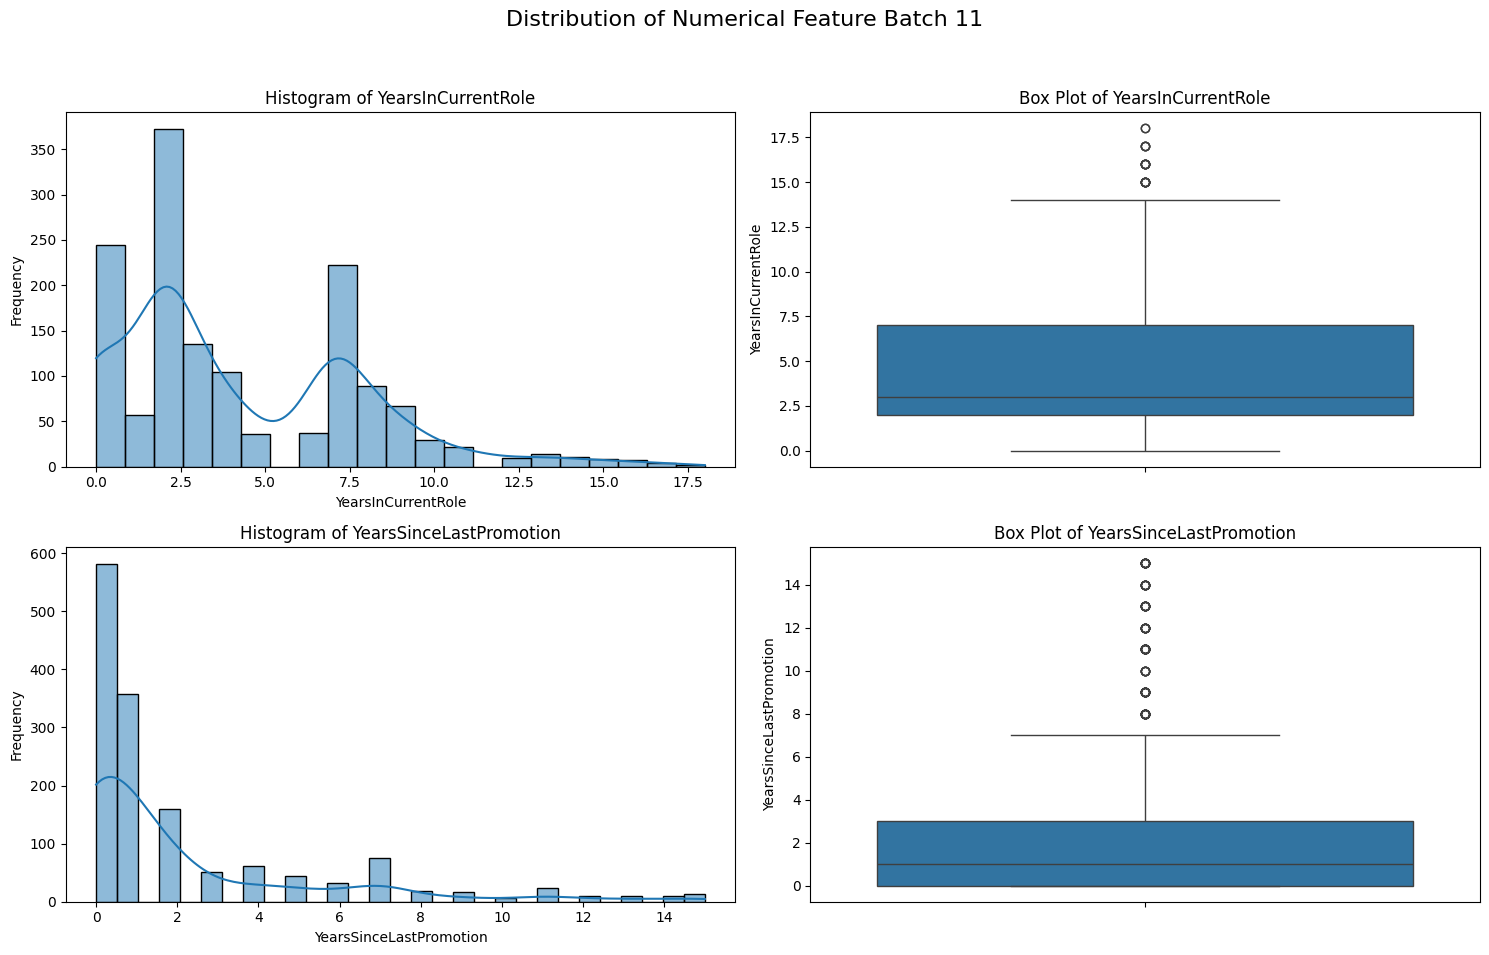

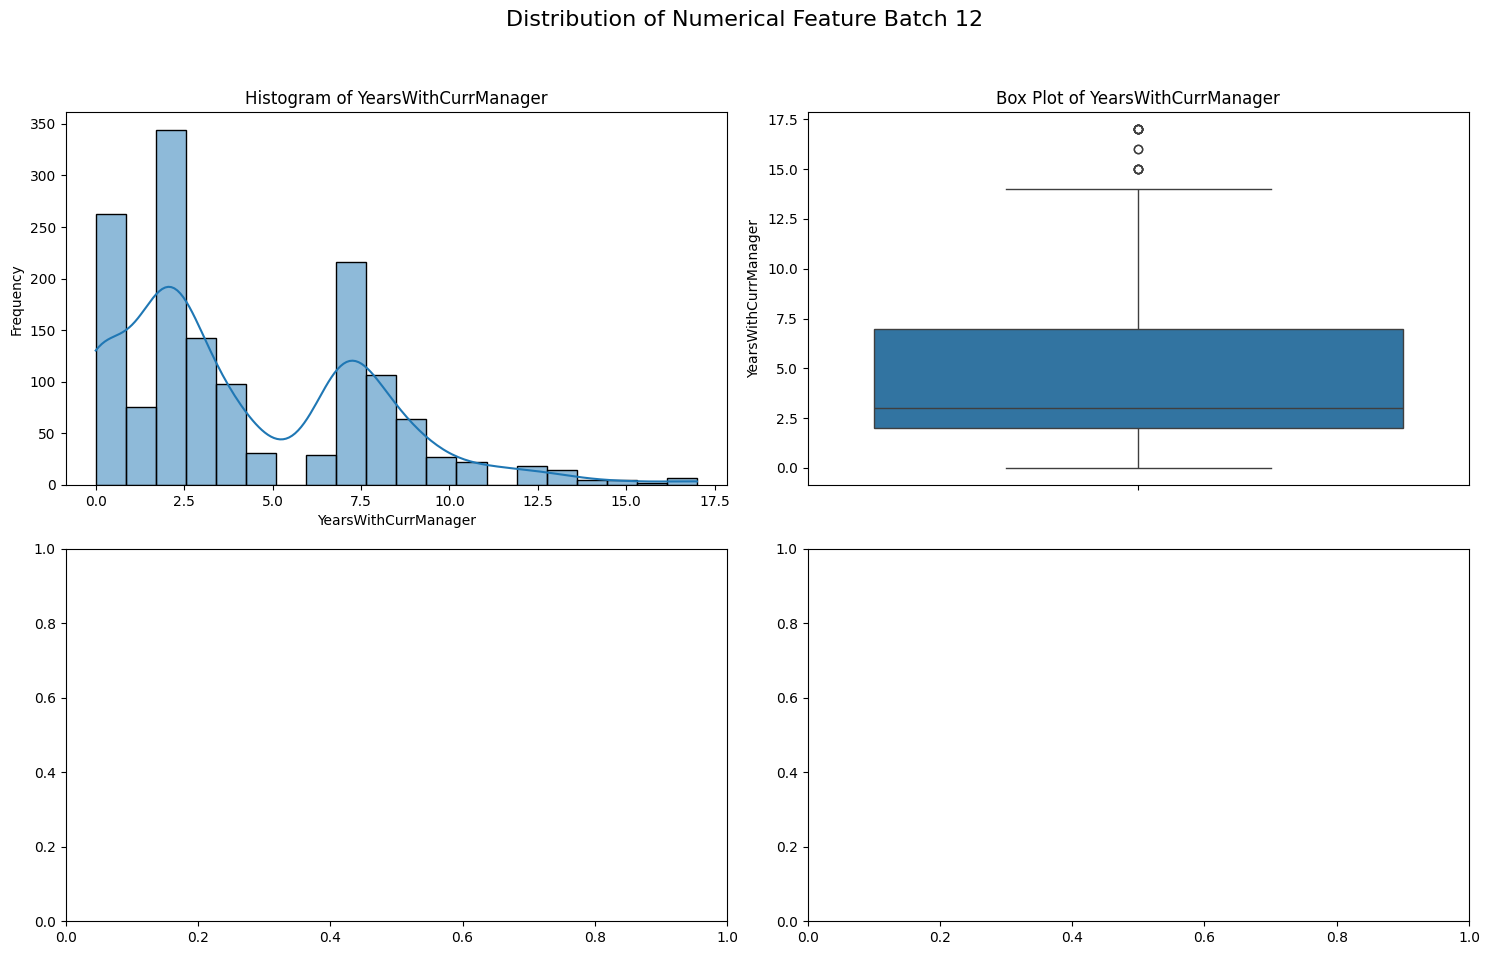

Histograms and box plots for numerical features have been generated.


In [11]:
numerical_cols = df_cleaned.select_dtypes(include=['int64']).columns

print(f"Identified {len(numerical_cols)} numerical columns for plotting:")
print(list(numerical_cols))

# Exclude 'Attrition' from numerical_cols if it's there as it's our target variable and already plotted
if 'Attrition' in numerical_cols:
    numerical_cols = numerical_cols.drop('Attrition')

# Define how many features to plot per figure (each feature will have a hist and a box plot)
features_per_figure = 2 # This means 2 features, or 4 total plots (2 hists + 2 boxplots) per figure
current_figure = None

for i, col in enumerate(numerical_cols):
    # Create a new figure for every `features_per_figure` features
    if i % features_per_figure == 0:
        # If not the first figure, close the previous one
        if current_figure is not None:
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

        # Create a new figure with `features_per_figure` rows and 2 columns (one for hist, one for box plot)
        fig, axes = plt.subplots(nrows=features_per_figure, ncols=2, figsize=(15, 5 * features_per_figure))
        fig.suptitle(f'Distribution of Numerical Feature Batch {int(i / features_per_figure) + 1}', fontsize=16)
        axes = axes.flatten() # Flatten the axes array for easier indexing
        current_figure = fig # Keep track of the current figure

    # Calculate indices for histogram and box plot within the flattened axes array
    # For feature `i`, its plots will be at `(i % features_per_figure) * 2` and `(i % features_per_figure) * 2 + 1`
    ax_offset = (i % features_per_figure) * 2
    hist_ax = axes[ax_offset]
    box_ax = axes[ax_offset + 1]

    # Plot Histogram
    sns.histplot(df_cleaned[col], kde=True, ax=hist_ax)
    hist_ax.set_title(f'Histogram of {col}')
    hist_ax.set_xlabel(col)
    hist_ax.set_ylabel('Frequency')

    # Plot Box Plot
    sns.boxplot(y=df_cleaned[col], ax=box_ax)
    box_ax.set_title(f'Box Plot of {col}')
    box_ax.set_ylabel(col)

# Display the last figure if there are any remaining plots
if current_figure is not None:
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Histograms and box plots for numerical features have been generated.")

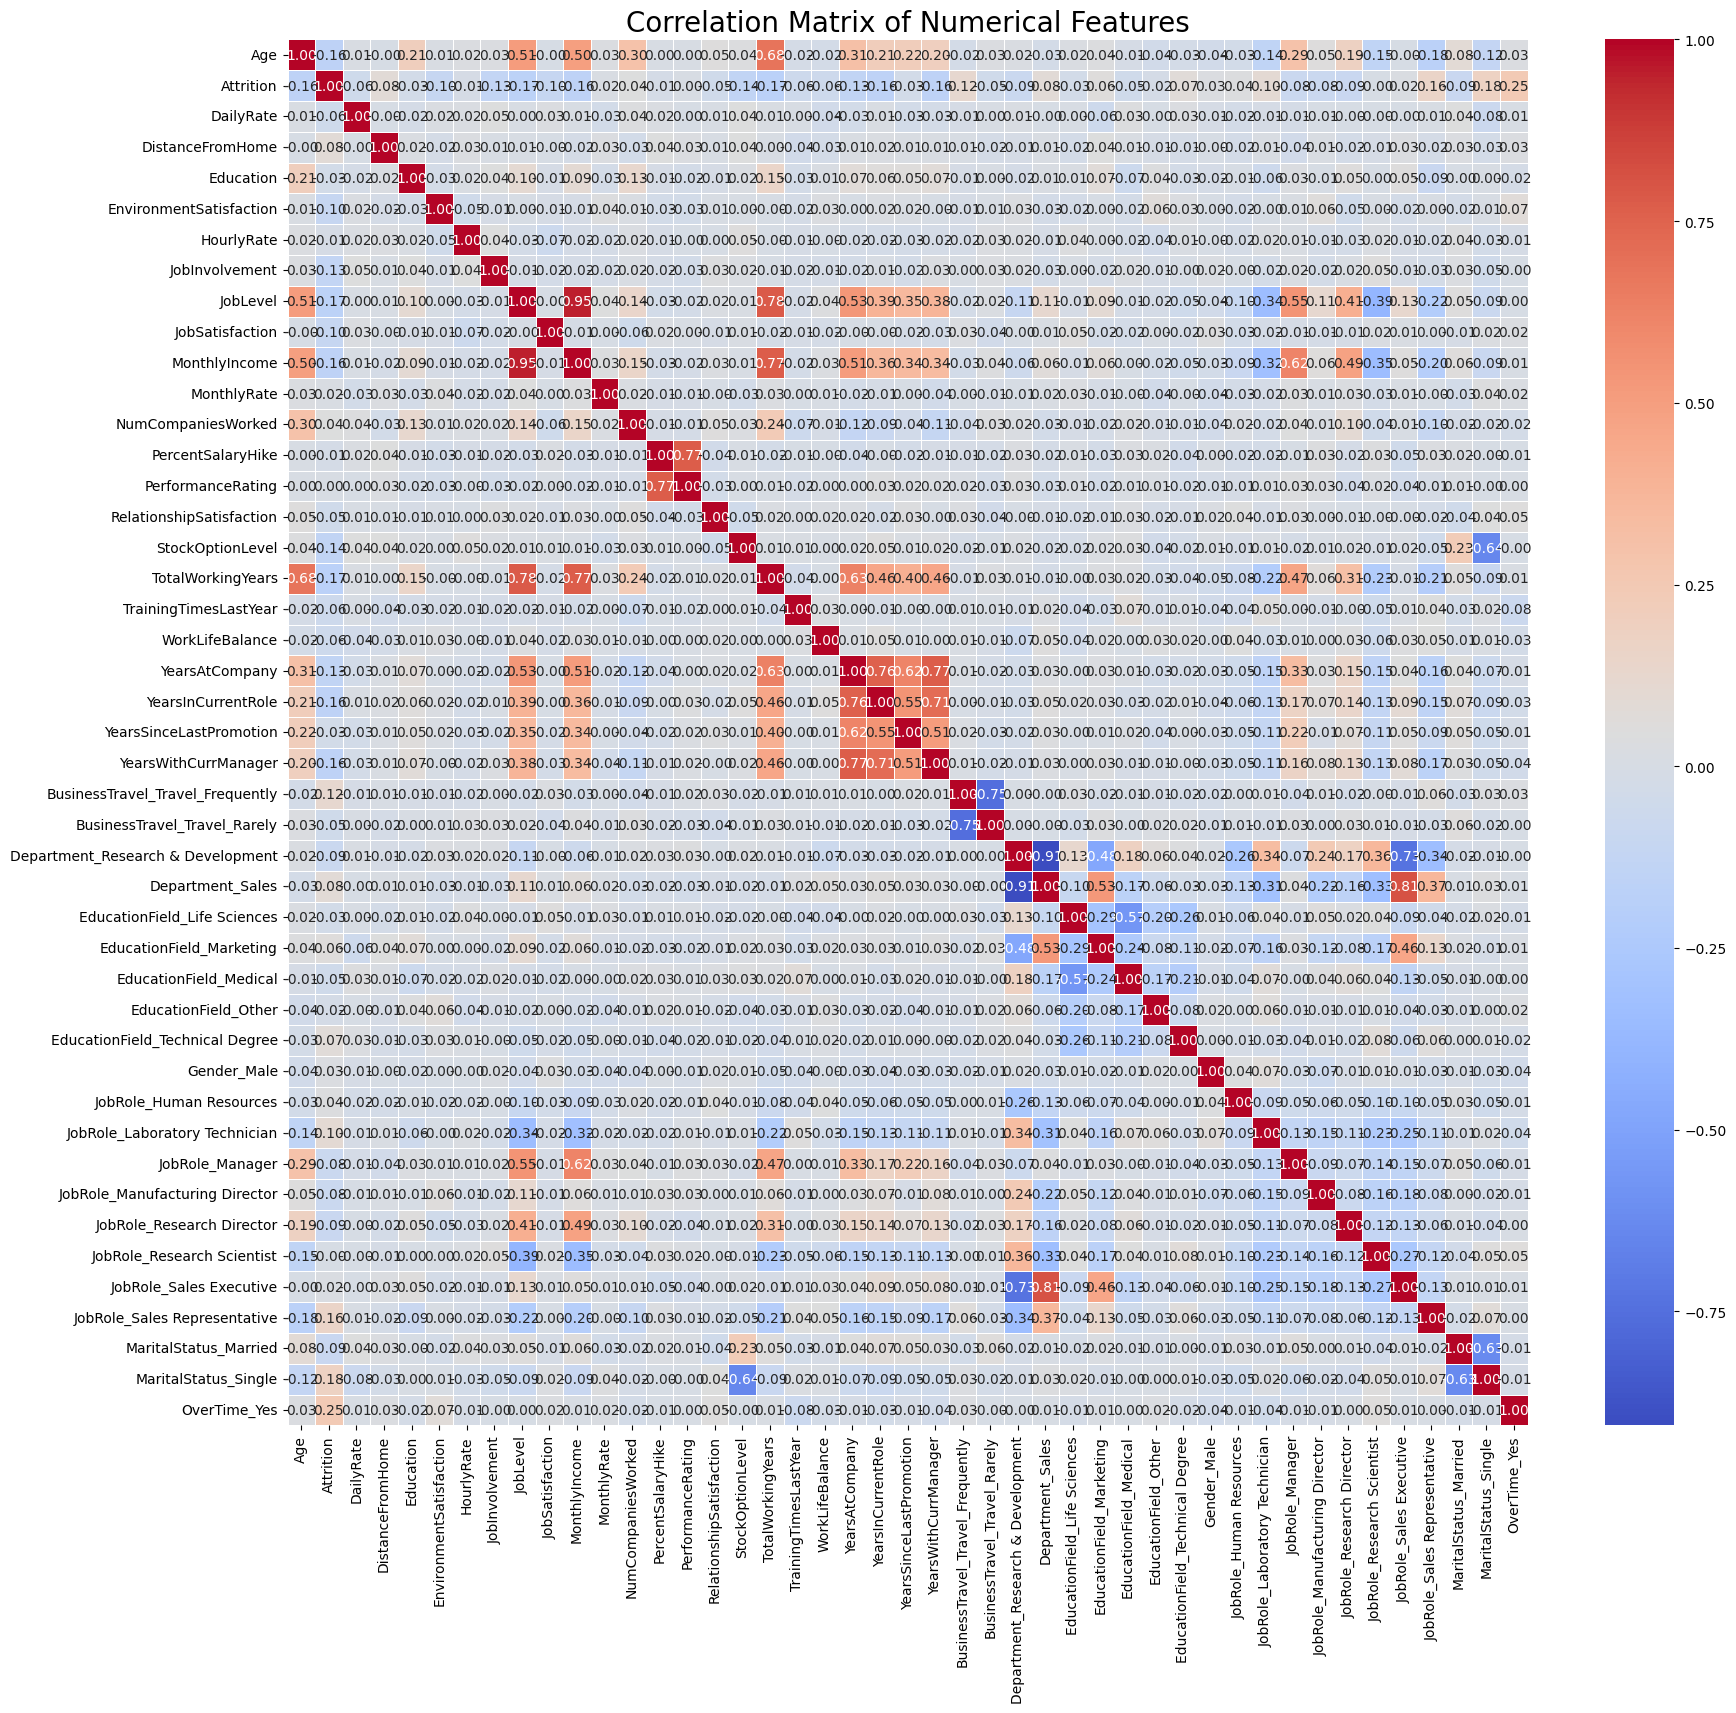

Correlation matrix heatmap displayed successfully.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the correlation matrix for all numerical columns
# The .corr() method by default calculates for numeric types, including bools (0s and 1s).
correlation_matrix = df_cleaned.corr()

# 2. Adjust the figure size for better visualization
plt.figure(figsize=(20, 18))

# 3. Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)

# 4. Add a title to the heatmap
plt.title('Correlation Matrix of Numerical Features', fontsize=20)

# 5. Display the plot
plt.show()

print("Correlation matrix heatmap displayed successfully.")

In [13]:
import numpy as np

# 1. Create a copy of df_cleaned named df_no_outliers
df_no_outliers = df_cleaned.copy()

print(f"Shape of df_cleaned before outlier removal: {df_cleaned.shape}")

# 2. Identify all numerical columns in df_no_outliers, excluding the 'Attrition' column
numerical_cols_for_outliers = df_no_outliers.select_dtypes(include=np.number).columns.tolist()
if 'Attrition' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('Attrition')

print(f"\nNumerical columns for outlier detection: {numerical_cols_for_outliers}")

# 3. For each column in numerical_cols_for_outliers, calculate IQR and remove outliers
for col in numerical_cols_for_outliers:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    initial_rows = df_no_outliers.shape[0]
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]
    removed_rows = initial_rows - df_no_outliers.shape[0]
    if removed_rows > 0:
        print(f"Removed {removed_rows} outliers from column '{col}'. New shape: {df_no_outliers.shape}")

# 4. Print the shape of df_cleaned before outlier removal and the shape of df_no_outliers after outlier removal
print(f"\nShape of df_cleaned before outlier removal: {df_cleaned.shape}")
print(f"Shape of df_no_outliers after outlier removal: {df_no_outliers.shape}")

Shape of df_cleaned before outlier removal: (1470, 45)

Numerical columns for outlier detection: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Removed 114 outliers from column 'MonthlyIncome'. New shape: (1356, 45)
Removed 47 outliers from column 'NumCompaniesWorked'. New shape: (1309, 45)
Removed 208 outliers from column 'PerformanceRating'. New shape: (1101, 45)
Removed 65 outliers from column 'StockOptionLevel'. New shape: (1036, 45)
Removed 49 outliers from column 'TotalWorkingYears'. New shape: (987, 45)
Removed 167 outliers from column 'TrainingTimesLastYear'. New shape: (820, 45)
Removed 

In [14]:
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target variable (y)
X = df_no_outliers.drop('Attrition', axis=1)
y = df_no_outliers['Attrition']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Identify numerical columns (all columns in X are numerical after one-hot encoding and excluding Attrition)
numerical_cols_X = X.select_dtypes(include=['int64', 'bool']).columns

# 2. Instantiate a StandardScaler object
scaler = StandardScaler()

# 3. Apply the fit_transform method to the features (X) to scale them
X_scaled = scaler.fit_transform(X)

# 4. Create a new DataFrame from the X_scaled array, preserving the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nFeatures scaled successfully using StandardScaler.")
print("First 5 rows of scaled features (X_scaled_df):")
print(X_scaled_df.head())

Shape of features (X): (699, 44)
Shape of target (y): (699,)

Features scaled successfully using StandardScaler.
First 5 rows of scaled features (X_scaled_df):
         Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
2   0.249333   1.417611         -0.902656  -0.836379                 1.171468   
3  -0.224586   1.465259         -0.780141   1.099478                 1.171468   
5  -0.343066   0.494759         -0.902656  -0.836379                 1.171468   
11 -0.698505  -1.641845          0.690050  -0.836379                 1.171468   
12 -0.461546  -0.345338          2.037725  -1.804308                -1.573301   

    HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
2     1.274549       -1.028080 -0.960599         0.259654      -1.019992  ...   
3    -0.486336        0.378237 -0.960599         0.259654      -0.723701  ...   
5     0.638674        0.378237 -0.960599         1.167145      -0.666179  ...   
11   -0.828730       -1.02808

In [15]:
from sklearn.decomposition import PCA

# 1. Instantiate a PCA object without specifying the number of components
pca = PCA()

# 2. Fit PCA to the scaled feature DataFrame X_scaled_df
pca.fit(X_scaled_df)

# 3. Access the explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio for each principal component:\n{explained_variance_ratio}")

# 4. Transform the X_scaled_df using the fitted PCA model to get the principal components
X_pca = pca.transform(X_scaled_df)

# 5. Create a new DataFrame from the principal components
X_pca_df = pd.DataFrame(X_pca, index=X_scaled_df.index)
X_pca_df.columns = [f'PC_{i+1}' for i in range(X_pca.shape[1])]

print(f"\nShape of X_pca_df after PCA: {X_pca_df.shape}")
print("First 5 rows of X_pca_df:")
print(X_pca_df.head())

Explained variance ratio for each principal component:
[1.04966696e-01 8.11048194e-02 5.34384954e-02 5.00634322e-02
 4.28918304e-02 3.73047553e-02 3.42759648e-02 3.28343062e-02
 3.11892133e-02 3.03996206e-02 2.85726135e-02 2.77883067e-02
 2.76771680e-02 2.69873710e-02 2.61753459e-02 2.49637312e-02
 2.47496215e-02 2.34090522e-02 2.33651923e-02 2.19057022e-02
 2.11655805e-02 2.04322182e-02 2.02683593e-02 1.96971777e-02
 1.89967799e-02 1.81939141e-02 1.79314193e-02 1.73293073e-02
 1.58778498e-02 1.46177928e-02 1.35286484e-02 1.24103249e-02
 7.71083420e-03 6.07829420e-03 5.60545455e-03 5.14937403e-03
 3.60769973e-03 2.66698084e-03 2.20528471e-03 2.01974526e-03
 3.45116295e-04 9.86059583e-05 0.00000000e+00 0.00000000e+00]

Shape of X_pca_df after PCA: (699, 44)
First 5 rows of X_pca_df:
        PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
2  -2.922807 -0.136138 -1.682618  0.300898 -0.649692 -0.020764 -0.491396   
3  -0.735563 -1.468794  1.406173  0.289493  3.172863  0

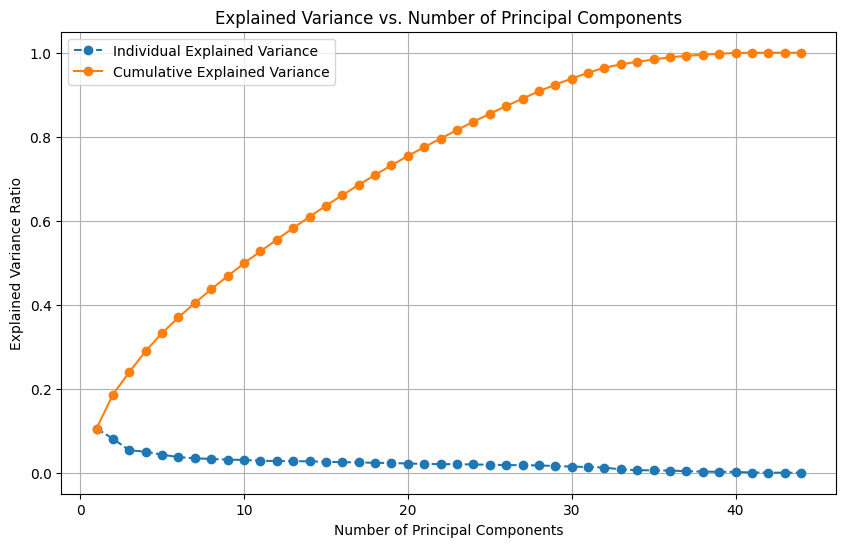

Plot of explained variance vs. number of principal components displayed successfully.


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(explained_variance_ratio)

# Plot explained variance ratio per component and cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cum_explained_variance, marker='o', linestyle='-', label='Cumulative Explained Variance')

plt.title('Explained Variance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.legend()
plt.show()

print("Plot of explained variance vs. number of principal components displayed successfully.")

In [17]:
import numpy as np

# Define the bins and labels for the Tenure_Category
bins = [-np.inf, 5, 10, 20, np.inf]
labels = ['Entry-level', 'Mid-level', 'Senior-level', 'Veteran']

# Create the 'Tenure_Category' column using pd.cut
df_no_outliers['Tenure_Category'] = pd.cut(df_no_outliers['TotalWorkingYears'], bins=bins, labels=labels, right=True)

print("Created 'Tenure_Category' column.")

# Verify the creation of the new column and the distribution of its categories
print("\nDistribution of 'Tenure_Category':")
print(df_no_outliers['Tenure_Category'].value_counts())

print("\nFirst 5 rows with new 'Tenure_Category' column:")
print(df_no_outliers[['TotalWorkingYears', 'Tenure_Category']].head())

Created 'Tenure_Category' column.

Distribution of 'Tenure_Category':
Tenure_Category
Mid-level       327
Entry-level     204
Senior-level    159
Veteran           9
Name: count, dtype: int64

First 5 rows with new 'Tenure_Category' column:
    TotalWorkingYears Tenure_Category
2                   7       Mid-level
3                   8       Mid-level
5                   8       Mid-level
11                 10       Mid-level
12                  5     Entry-level


In [18]:
df_no_outliers['Performance_Score'] = df_no_outliers['PerformanceRating'] * df_no_outliers['PercentSalaryHike']

print("Created 'Performance_Score' column.")

# Verify the creation of the new column and its distribution
print("\nDescriptive statistics for 'Performance_Score':")
print(df_no_outliers['Performance_Score'].describe())

print("\nFirst 5 rows with new 'Performance_Score' column:")
print(df_no_outliers[['PerformanceRating', 'PercentSalaryHike', 'Performance_Score']].head())

Created 'Performance_Score' column.

Descriptive statistics for 'Performance_Score':
count    699.000000
mean      42.583691
std        7.339286
min       33.000000
25%       36.000000
50%       42.000000
75%       48.000000
max       57.000000
Name: Performance_Score, dtype: float64

First 5 rows with new 'Performance_Score' column:
    PerformanceRating  PercentSalaryHike  Performance_Score
2                   3                 15                 45
3                   3                 11                 33
5                   3                 13                 39
11                  3                 12                 36
12                  3                 17                 51


In [19]:
df_no_outliers['Engagement_Score'] = df_no_outliers['JobInvolvement'] + \
                                     df_no_outliers['EnvironmentSatisfaction'] + \
                                     df_no_outliers['JobSatisfaction'] + \
                                     df_no_outliers['RelationshipSatisfaction'] + \
                                     df_no_outliers['WorkLifeBalance']

print("Created 'Engagement_Score' column.")

# Verify the creation of the new column and its distribution
print("\nDescriptive statistics for 'Engagement_Score':")
print(df_no_outliers['Engagement_Score'].describe())

print("\nFirst 5 rows with new 'Engagement_Score' column:")
print(df_no_outliers[['JobInvolvement', 'EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance', 'Engagement_Score']].head())

Created 'Engagement_Score' column.

Descriptive statistics for 'Engagement_Score':
count    699.000000
mean      13.629471
std        2.220971
min        6.000000
25%       12.000000
50%       14.000000
75%       15.000000
max       19.000000
Name: Engagement_Score, dtype: float64

First 5 rows with new 'Engagement_Score' column:
    JobInvolvement  EnvironmentSatisfaction  JobSatisfaction  \
2                2                        4                3   
3                3                        4                3   
5                3                        4                4   
11               2                        4                3   
12               3                        1                3   

    RelationshipSatisfaction  WorkLifeBalance  Engagement_Score  
2                          2                3                14  
3                          3                3                16  
5                          3                2                16  
11                 

In [20]:
print(f"Shape of df_no_outliers before one-hot encoding Tenure_Category: {df_no_outliers.shape}")

# One-hot encode the 'Tenure_Category' column
df_no_outliers = pd.get_dummies(df_no_outliers, columns=['Tenure_Category'], drop_first=True, dtype=int)

print("One-hot encoded 'Tenure_Category' column.")

# Display the first few rows with the new encoded columns
print("\nFirst 5 rows of df_no_outliers after one-hot encoding 'Tenure_Category':")
print(df_no_outliers.head())

print(f"\nShape of df_no_outliers after one-hot encoding Tenure_Category: {df_no_outliers.shape}")

Shape of df_no_outliers before one-hot encoding Tenure_Category: (699, 48)
One-hot encoded 'Tenure_Category' column.

First 5 rows of df_no_outliers after one-hot encoding 'Tenure_Category':
    Age  Attrition  DailyRate  DistanceFromHome  Education  \
2    37          1       1373                 2          2   
3    33          0       1392                 3          4   
5    32          0       1005                 2          2   
11   29          0        153                15          2   
12   31          0        670                26          1   

    EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
2                         4          92               2         1   
3                         4          56               3         1   
5                         4          79               3         1   
11                        4          49               2         2   
12                        1          31               3         1   

    JobSatisfaction  

In [21]:
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) and target variable (y)
X = df_no_outliers.drop('Attrition', axis=1)
y = df_no_outliers['Attrition']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 2. Instantiate a StandardScaler object
scaler = StandardScaler()

# 3. Apply the fit_transform method to the features (X) to scale them
X_scaled = scaler.fit_transform(X)

# 4. Create a new DataFrame from the X_scaled array, preserving the original column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nFeatures scaled successfully using StandardScaler.")
print("First 5 rows of scaled features (X_scaled_df):")
print(X_scaled_df.head())

Shape of features (X): (699, 49)
Shape of target (y): (699,)

Features scaled successfully using StandardScaler.
First 5 rows of scaled features (X_scaled_df):
         Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
2   0.249333   1.417611         -0.902656  -0.836379                 1.171468   
3  -0.224586   1.465259         -0.780141   1.099478                 1.171468   
5  -0.343066   0.494759         -0.902656  -0.836379                 1.171468   
11 -0.698505  -1.641845          0.690050  -0.836379                 1.171468   
12 -0.461546  -0.345338          2.037725  -1.804308                -1.573301   

    HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
2     1.274549       -1.028080 -0.960599         0.259654      -1.019992  ...   
3    -0.486336        0.378237 -0.960599         0.259654      -0.723701  ...   
5     0.638674        0.378237 -0.960599         1.167145      -0.666179  ...   
11   -0.828730       -1.02808

In [22]:
from sklearn.decomposition import PCA

# 1. Instantiate a PCA object without specifying the number of components
pca_new = PCA()

# 2. Fit PCA to the scaled feature DataFrame X_scaled_df
pca_new.fit(X_scaled_df)

# 3. Access the explained variance ratio for each principal component (optional, but good for understanding)
explained_variance_ratio_new = pca_new.explained_variance_ratio_
print(f"Explained variance ratio for each principal component:\n{explained_variance_ratio_new}")

# 4. Transform the X_scaled_df using the fitted PCA model to get the principal components
X_pca_new = pca_new.transform(X_scaled_df)

# 5. Create a new DataFrame from the principal components, preserving the original index
X_pca_df_new = pd.DataFrame(X_pca_new, index=X_scaled_df.index)

# 6. Assign meaningful column names to X_pca_df_new
X_pca_df_new.columns = [f'PC_{i+1}' for i in range(X_pca_new.shape[1])]

print(f"\nShape of X_pca_df_new after PCA: {X_pca_df_new.shape}")
print("First 5 rows of X_pca_df_new:")
print(X_pca_df_new.head())

Explained variance ratio for each principal component:
[1.00375651e-01 7.39227385e-02 5.20860034e-02 4.78199766e-02
 4.46332817e-02 4.15956880e-02 3.66323694e-02 3.45774231e-02
 3.33266935e-02 3.05086880e-02 2.90651614e-02 2.84084636e-02
 2.73892956e-02 2.55562116e-02 2.46006728e-02 2.41061120e-02
 2.27133389e-02 2.17311525e-02 2.13130715e-02 2.10554256e-02
 2.01676123e-02 1.96466702e-02 1.86574598e-02 1.82827912e-02
 1.80290569e-02 1.77166058e-02 1.67122066e-02 1.63014039e-02
 1.54949558e-02 1.44928486e-02 1.37516550e-02 1.30205411e-02
 1.20451667e-02 1.09805107e-02 7.19942944e-03 5.52737557e-03
 5.20852849e-03 4.57097480e-03 3.21801367e-03 2.34035770e-03
 1.88928799e-03 1.83681653e-03 1.10222979e-03 3.09055145e-04
 8.10277269e-05 6.74787472e-18 4.36376170e-18 0.00000000e+00
 0.00000000e+00]

Shape of X_pca_df_new after PCA: (699, 49)
First 5 rows of X_pca_df_new:
        PC_1      PC_2      PC_3      PC_4      PC_5      PC_6      PC_7  \
2  -2.841098 -0.548572 -1.192699  0.958879 -0.

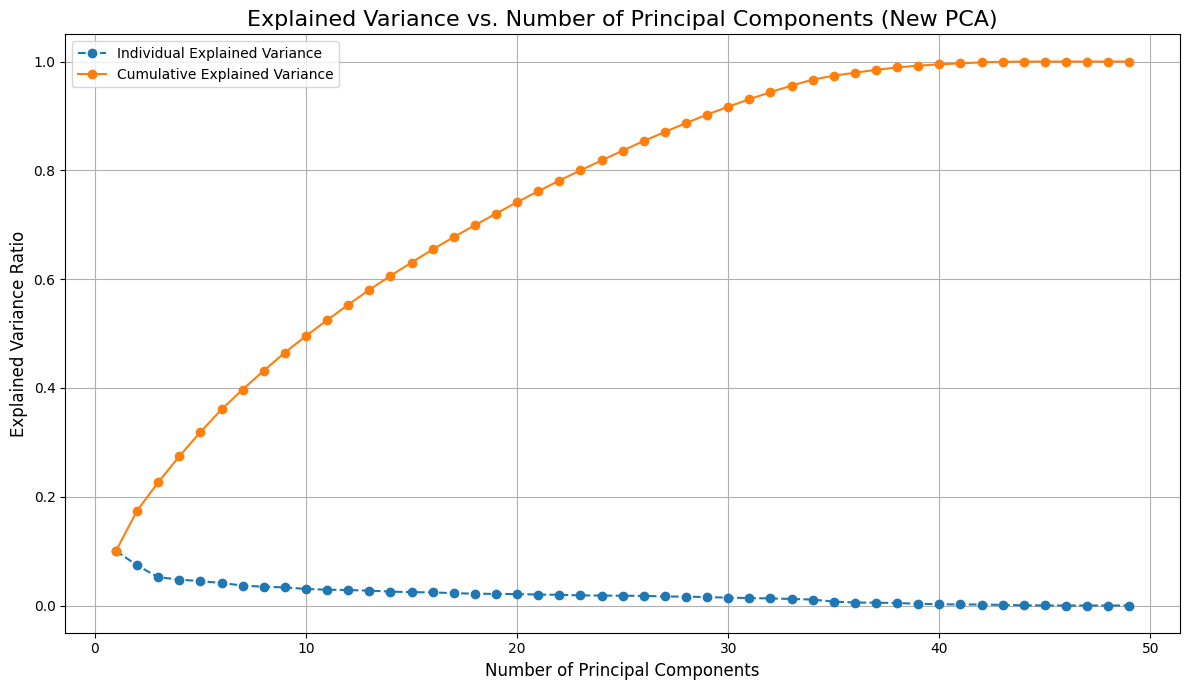

Plot of explained variance vs. number of principal components for the new PCA displayed successfully.


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate cumulative explained variance for the new PCA results
cum_explained_variance_new = np.cumsum(explained_variance_ratio_new)

# Plot explained variance ratio per component and cumulative explained variance
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(explained_variance_ratio_new) + 1), explained_variance_ratio_new, marker='o', linestyle='--', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio_new) + 1), cum_explained_variance_new, marker='o', linestyle='-', label='Cumulative Explained Variance')

plt.title('Explained Variance vs. Number of Principal Components (New PCA)', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

print("Plot of explained variance vs. number of principal components for the new PCA displayed successfully.")

In [24]:
from sklearn.model_selection import train_test_split

# 1. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca_df_new, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (489, 49)
Shape of X_test: (210, 49)
Shape of y_train: (489,)
Shape of y_test: (210,)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# 2. Instantiate a LogisticRegression object
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# 3. Train the logistic regression model
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

# 4. Make predictions on the test data
y_pred = log_reg_model.predict(X_test)
# Predict probabilities for AUC-ROC
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]
print("Predictions made on the test set.")

# 6. Calculate the accuracy, precision, recall, F1-score, and AUC-ROC
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# 7. Print the calculated evaluation metrics
print(f"\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Logistic Regression model trained successfully.
Predictions made on the test set.

Model Performance:
Accuracy: 0.8429
Precision: 0.4839
Recall: 0.4688
F1-Score: 0.4762
AUC-ROC: 0.7728


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# 1. Reset df_no_outliers to the state before the erroneous one-hot encoding
# Assuming df_cleaned is still available and represents the state before outlier removal and feature engineering
df_no_outliers = df_cleaned.copy()

# Re-apply outlier removal
numerical_cols_for_outliers = df_no_outliers.select_dtypes(include=np.number).columns.tolist()
if 'Attrition' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('Attrition')

for col in numerical_cols_for_outliers:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= lower_bound) & (df_no_outliers[col] <= upper_bound)]

# Re-apply feature engineering
bins = [-np.inf, 5, 10, 20, np.inf]
labels = ['Entry-level', 'Mid-level', 'Senior-level', 'Veteran']
df_no_outliers['Tenure_Category'] = pd.cut(df_no_outliers['TotalWorkingYears'], bins=bins, labels=labels, right=True)
df_no_outliers['Performance_Score'] = df_no_outliers['PerformanceRating'] * df_no_outliers['PercentSalaryHike']
df_no_outliers['Engagement_Score'] = df_no_outliers['JobInvolvement'] + \
                                     df_no_outliers['EnvironmentSatisfaction'] + \
                                     df_no_outliers['JobSatisfaction'] + \
                                     df_no_outliers['RelationshipSatisfaction'] + \
                                     df_no_outliers['WorkLifeBalance']

# 2. One-hot encode the 'Tenure_Category' column correctly
df_no_outliers = pd.get_dummies(df_no_outliers, columns=['Tenure_Category'], drop_first=True, dtype=int)

# Separate features (X) and target variable (y) again
X = df_no_outliers.drop('Attrition', axis=1)
y = df_no_outliers['Attrition']

# Scale the features again
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Apply PCA again
pca_new = PCA()
pca_new.fit(X_scaled_df)
X_pca_new = pca_new.transform(X_scaled_df)
X_pca_df_new = pd.DataFrame(X_pca_new, index=X_scaled_df.index)
X_pca_df_new.columns = [f'PC_{i+1}' for i in range(X_pca_new.shape[1])]

# Split the data again
X_train, X_test, y_train, y_test = train_test_split(X_pca_df_new, y, test_size=0.3, random_state=42)


print("Beginning Decision Tree Classifier training...")

# 2. Instantiate a DecisionTreeClassifier object
dt_model = DecisionTreeClassifier(random_state=42)

# 3. Train the Decision Tree Classifier
dt_model.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully.")

# 4. Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)
# Predict probabilities for AUC-ROC
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
print("Predictions made on the test set.")

# 5. Calculate the accuracy, precision, recall, and F1-score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
auc_roc_dt = roc_auc_score(y_test, y_pred_proba_dt)

# 6. Print the calculated evaluation metrics
print(f"\nDecision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"AUC-ROC: {auc_roc_dt:.4f}")

Beginning Decision Tree Classifier training...
Decision Tree Classifier trained successfully.
Predictions made on the test set.

Decision Tree Model Performance:
Accuracy: 0.7810
Precision: 0.3250
Recall: 0.4062
F1-Score: 0.3611
AUC-ROC: 0.6273


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Beginning Random Forest Classifier training...")

# 1. Instantiate a RandomForestClassifier object
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the Random Forest Classifier
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully.")

# 3. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)
# Predict probabilities for AUC-ROC
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("Predictions made on the test set.")

# 4. Calculate the accuracy, precision, recall, F1-score, and AUC-ROC
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

# 5. Print the calculated evaluation metrics
print(f"\nRandom Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_roc_rf:.4f}")

Beginning Random Forest Classifier training...
Random Forest Classifier trained successfully.
Predictions made on the test set.

Random Forest Model Performance:
Accuracy: 0.8571
Precision: 0.7500
Recall: 0.0938
F1-Score: 0.1667
AUC-ROC: 0.6524


Shape of X_train (no PCA): (489, 49)
Shape of X_test (no PCA): (210, 49)
Shape of y_train: (489,)
Shape of y_test: (210,)

Random Forest Classifier trained successfully on scaled features (no PCA).

Feature importances extracted and sorted.


/tmp/ipython-input-3432484157.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_feature_importances.head(10).values, y=sorted_feature_importances.head(10).index, palette='viridis')


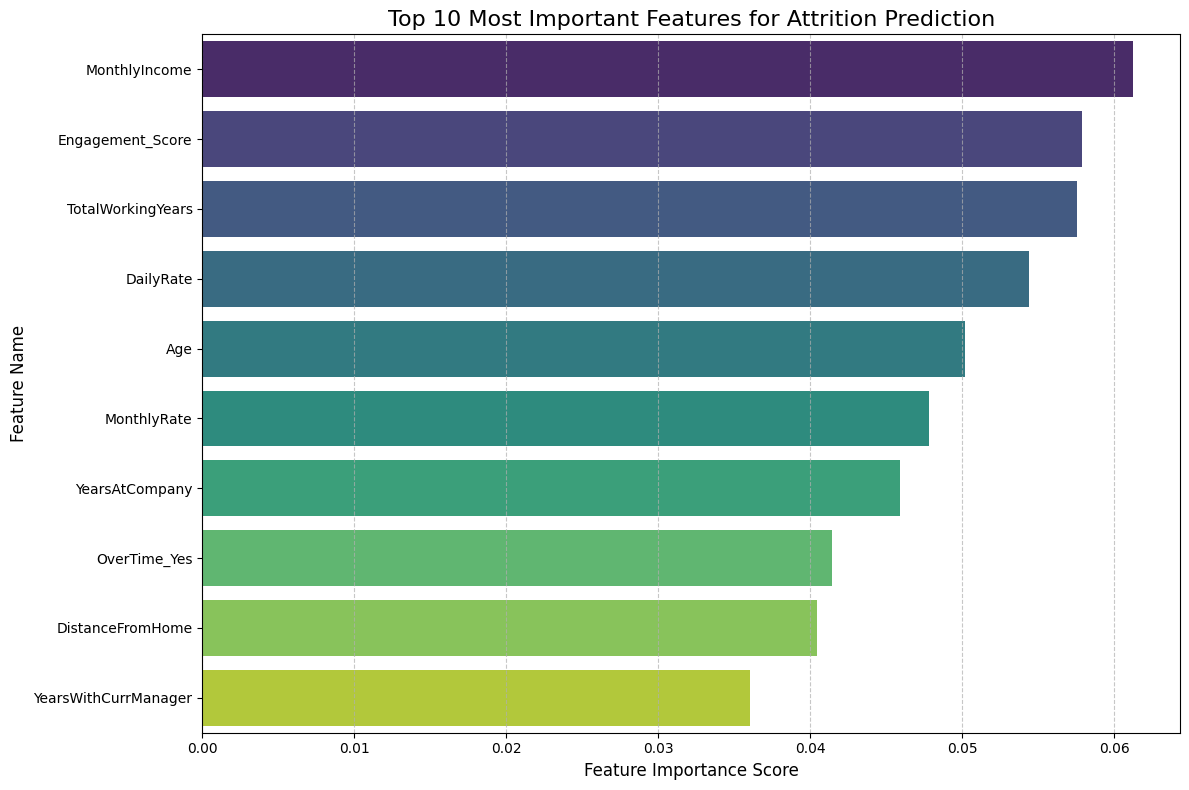


Top 10 most important features visualized.

Top 10 Most Important Features:
MonthlyIncome           0.061277
Engagement_Score        0.057919
TotalWorkingYears       0.057566
DailyRate               0.054435
Age                     0.050173
MonthlyRate             0.047833
YearsAtCompany          0.045914
OverTime_Yes            0.041453
DistanceFromHome        0.040461
YearsWithCurrManager    0.036021
dtype: float64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# 1. Split the data into training and testing sets using X_scaled_df and y
X_train_no_pca, X_test_no_pca, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

print(f"Shape of X_train (no PCA): {X_train_no_pca.shape}")
print(f"Shape of X_test (no PCA): {X_test_no_pca.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 2. Instantiate a RandomForestClassifier
rf_model_no_pca = RandomForestClassifier(random_state=42)

# 3. Train the Random Forest Classifier on the non-PCA scaled training data
rf_model_no_pca.fit(X_train_no_pca, y_train)
print("\nRandom Forest Classifier trained successfully on scaled features (no PCA).")

# 4. Extract feature importances
feature_importances = pd.Series(rf_model_no_pca.feature_importances_, index=X_scaled_df.columns)

# 5. Create a pandas Series or DataFrame of these feature importances, sorted in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("\nFeature importances extracted and sorted.")

# 6. Visualize the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importances.head(10).values, y=sorted_feature_importances.head(10).index, palette='viridis')
plt.title('Top 10 Most Important Features for Attrition Prediction', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features visualized.")

# 7. Print the top 10 most important features and their scores
print("\nTop 10 Most Important Features:")
print(sorted_feature_importances.head(10))

Shape of X_train (no PCA): (489, 49)
Shape of X_test (no PCA): (210, 49)
Shape of y_train: (489,)
Shape of y_test: (210,)

Random Forest Classifier trained successfully on scaled features (no PCA).

Feature importances extracted and sorted.


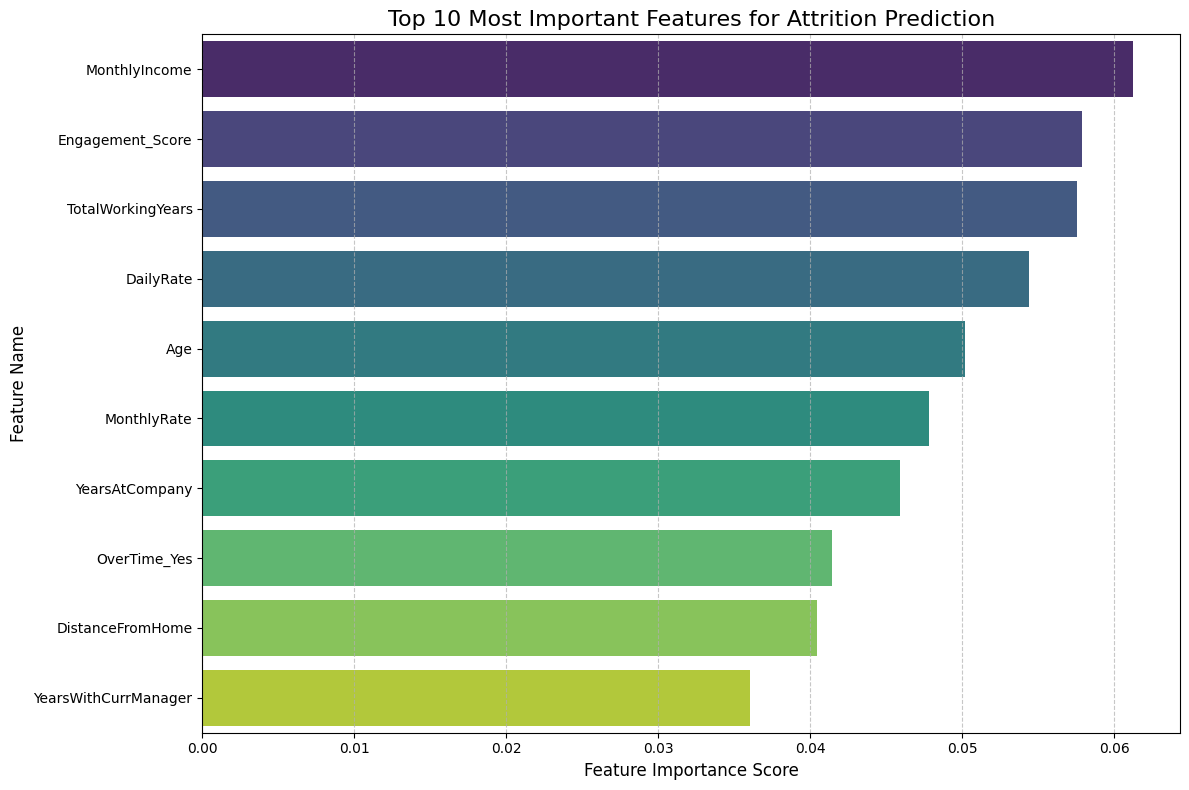


Top 10 most important features visualized.

Top 10 Most Important Features:
MonthlyIncome           0.061277
Engagement_Score        0.057919
TotalWorkingYears       0.057566
DailyRate               0.054435
Age                     0.050173
MonthlyRate             0.047833
YearsAtCompany          0.045914
OverTime_Yes            0.041453
DistanceFromHome        0.040461
YearsWithCurrManager    0.036021
dtype: float64


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# 1. Split the data into training and testing sets using X_scaled_df and y
X_train_no_pca, X_test_no_pca, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

print(f"Shape of X_train (no PCA): {X_train_no_pca.shape}")
print(f"Shape of X_test (no PCA): {X_test_no_pca.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 2. Instantiate a RandomForestClassifier
rf_model_no_pca = RandomForestClassifier(random_state=42)

# 3. Train the Random Forest Classifier on the non-PCA scaled training data
rf_model_no_pca.fit(X_train_no_pca, y_train)
print("\nRandom Forest Classifier trained successfully on scaled features (no PCA).")

# 4. Extract feature importances
feature_importances = pd.Series(rf_model_no_pca.feature_importances_, index=X_scaled_df.columns)

# 5. Create a pandas Series or DataFrame of these feature importances, sorted in descending order
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("\nFeature importances extracted and sorted.")

# 6. Visualize the top 10 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_feature_importances.head(10).values, y=sorted_feature_importances.head(10).index, palette='viridis', hue=sorted_feature_importances.head(10).index, legend=False)
plt.title('Top 10 Most Important Features for Attrition Prediction', fontsize=16)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features visualized.")

# 7. Print the top 10 most important features and their scores
print("\nTop 10 Most Important Features:")
print(sorted_feature_importances.head(10))


In [30]:
import joblib
import os

# Define paths for saving
output_dir = '/content/streamlit_data'
os.makedirs(output_dir, exist_ok=True)

X_scaled_df_path = os.path.join(output_dir, 'X_scaled_df.pkl')
y_path = os.path.join(output_dir, 'y.pkl')
rf_model_path = os.path.join(output_dir, 'rf_model.pkl')
sorted_feature_importances_path = os.path.join(output_dir, 'sorted_feature_importances.pkl')

# Save the pre-processed features (X_scaled_df) and target (y)
joblib.dump(X_scaled_df, X_scaled_df_path)
joblib.dump(y, y_path)
print(f"X_scaled_df and y saved to {output_dir}")

# Save the trained Random Forest model
joblib.dump(rf_model_no_pca, rf_model_path)
print(f"Random Forest model saved to {rf_model_path}")

# Save the sorted feature importances
joblib.dump(sorted_feature_importances, sorted_feature_importances_path)
print(f"Sorted feature importances saved to {sorted_feature_importances_path}")

print("All necessary data and model components have been saved for the Streamlit app.")

X_scaled_df and y saved to /content/streamlit_data
Random Forest model saved to /content/streamlit_data/rf_model.pkl
Sorted feature importances saved to /content/streamlit_data/sorted_feature_importances.pkl
All necessary data and model components have been saved for the Streamlit app.


In [31]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 9.0 MB/s eta 0:00:00


In [52]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Page Configuration ---
st.set_page_config(page_title="HR Model Selection & Analytics", layout="wide")

# --- Data Loading ---
@st.cache_data
def load_data():
    return pd.read_csv('cleaned_employee_attrition.csv')

df = load_data()

# --- Model Training Function ---
@st.cache_resource
def train_selected_model(data, model_type):
    X = data.drop('Attrition', axis=1)
    y = data['Attrition']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if model_type == "Logistic Regression":
        model = LogisticRegression(max_iter=2000, random_state=42)
    elif model_type == "Decision Tree":
        model = DecisionTreeClassifier(random_state=42)
    else: # Random Forest
        model = RandomForestClassifier(n_estimators=100, random_state=42)

    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    return model, acc, X.columns

# --- SIDEBAR: Model Selection & Navigation ---
st.sidebar.title("⚙️ Settings")
selected_model_name = st.sidebar.selectbox(
    "Choose Prediction Model:",
    ["Logistic Regression", "Decision Tree", "Random Forest"]
)

# Train the selected model
model, accuracy, feature_cols = train_selected_model(df, selected_model_name)

st.sidebar.success(f"**{selected_model_name}** selected.")
st.sidebar.metric("Model Accuracy", f"{accuracy:.2%}")

st.sidebar.divider()

menu = st.sidebar.radio("Go to Page:", [
    "Attrition Prediction",
    "High-Risk Employee List",
    "Job Satisfaction & Performance",
    "Side-by-Side Comparisons"
])

# --- 1. ATTRITION PREDICTION ---
if menu == "Attrition Prediction":
    st.title("🔍 Attrition Risk Predictor")
    st.write(f"Currently using **{selected_model_name}** to predict risk.")

    col1, col2 = st.columns([1, 1])
    with col1:
        st.subheader("Input Details")
        age = st.slider("Age", 18, 60, 30)
        income = st.number_input("Monthly Income ($)", 1000, 20000, 5000)
        overtime = st.selectbox("Overtime", ["Yes", "No"])
        job_sat = st.slider("Job Satisfaction", 1, 4, 3)
        env_sat = st.slider("Environment Satisfaction", 1, 4, 3)
        dist = st.slider("Distance From Home (km)", 1, 30, 5)

    # Prepare Prediction Data
    input_data = pd.DataFrame([df.drop('Attrition', axis=1).median()], columns=feature_cols)
    input_data['Age'] = age
    input_data['MonthlyIncome'] = income
    input_data['OverTime_Yes'] = 1 if overtime == "Yes" else 0
    input_data['JobSatisfaction'] = job_sat
    input_data['EnvironmentSatisfaction'] = env_sat
    input_data['DistanceFromHome'] = dist

    risk_prob = model.predict_proba(input_data)[0][1] * 100

    with col2:
        st.subheader("Results")
        fig = go.Figure(go.Indicator(
            mode = "gauge+number",
            value = risk_prob,
            title = {'text': "Risk Percentage"},
            gauge = {'axis': {'range': [0, 100]},
                     'bar': {'color': "darkblue"},
                     'steps': [
                         {'range': [0, 35], 'color': "green"},
                         {'range': [35, 70], 'color': "orange"},
                         {'range': [70, 100], 'color': "red"}]}
        ))
        st.plotly_chart(fig, use_container_width=True)

# --- 2. HIGH-RISK EMPLOYEE LIST ---
elif menu == "High-Risk Employee List":
    st.title("🚨 High-Risk Employee List")
    st.write(f"Calculating risk rankings using **{selected_model_name}**.")

    active_df = df[df['Attrition'] == 0].copy()
    active_df['Risk_Score'] = (model.predict_proba(active_df.drop('Attrition', axis=1))[:, 1] * 100).round(2)

    high_risk = active_df.sort_values(by='Risk_Score', ascending=False).head(10)
    st.dataframe(high_risk[['Risk_Score', 'Age', 'MonthlyIncome', 'JobSatisfaction', 'YearsAtCompany']].style.background_gradient(cmap='Reds', subset=['Risk_Score']))

    fig = px.bar(high_risk, x='Risk_Score', y=high_risk.index.astype(str), orientation='h',
                 title="Top 10 High Risk Employees", color='Risk_Score', color_continuous_scale='Reds')
    st.plotly_chart(fig)

# --- 3. JOB SATISFACTION & PERFORMANCE INSIGHTS ---
elif menu == "Job Satisfaction & Performance":
    st.title("🌟 Performance Insights")
    stars = df[(df['JobSatisfaction'] == 4) & (df['PerformanceRating'] >= 3)]

    col1, col2 = st.columns(2)
    col1.metric("Total Happy Top-Performers", len(stars))
    col2.metric("Company Avg. Satisfaction", round(df['JobSatisfaction'].mean(), 2))

    st.write("### List of Top Performers")
    st.dataframe(stars[['Age', 'MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'Department_Sales', 'YearsAtCompany']])

    fig = px.box(df, x="PerformanceRating", y="MonthlyIncome", color="Attrition", title="Income Distribution by Performance and Attrition")
    st.plotly_chart(fig)

# --- 4. SIDE-BY-SIDE COMPARISONS ---
elif menu == "Side-by-Side Comparisons":
    st.title("⚖️ Employee Comparison")

    c1, c2 = st.columns(2)
    id_a = c1.selectbox("Select Employee A (Index)", df.index)
    id_b = c2.selectbox("Select Employee B (Index)", df.index, index=1)

    comp_df = df.loc[[id_a, id_b]].T
    comp_df.columns = [f"Employee {id_a}", f"Employee {id_b}"]

    metrics = ['Age', 'MonthlyIncome', 'JobSatisfaction', 'PerformanceRating', 'WorkLifeBalance', 'YearsAtCompany']
    st.dataframe(comp_df.loc[metrics])

    # Visual Radar Comparison
    fig = go.Figure()
    for eid in [id_a, id_b]:
        fig.add_trace(go.Scatterpolar(
            r = [df.loc[eid, m] / df[m].max() for m in metrics],
            theta = metrics, fill = 'toself', name = f'Employee {eid}'
        ))
    fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])), title="Normalized Comparison")
    st.plotly_chart(fig)

Overwriting app.py


In [53]:
!wget -q -O - ipv4.icanhazip.com

34.132.141.79


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://cyan-hounds-hammer.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.132.141.79:8501

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026-01-31 07:12:58.401 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-01-